# IEMOCAP EDA

**Source:** HuggingFace `AbstractTTS/IEMOCAP` (cached locally after first run)  
**Grain:** one row = one IEMOCAP utterance  

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import plotly.graph_objects as go

# Fix all random operations so results are reproducible across runs
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Global plot styling — whitegrid keeps numeric axes readable
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

---
## Step 1 — Load & Overview

In [2]:
# First run downloads ~1.4 GB from HuggingFace and caches locally.
# Every subsequent run loads instantly from the local cache.
ds = load_dataset("AbstractTTS/IEMOCAP", split="train")

# Convert to pandas DataFrame for tabular analysis.
# The audio column stores raw WAV bytes as Python dicts — keeping it in df would
# bloat every pandas operation with ~1.4 GB of binary data. We drop it from df
# but keep ds alive: Step 6 (Audio Analysis) accesses audio on demand via
# ds[i]["audio"], which HuggingFace decodes lazily into a numpy array per utterance.
df = ds.to_pandas()
df = df.drop(columns=["audio"])

print(f"Shape:   {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory:  {df.memory_usage(deep=True).sum() / 1_048_576:.2f} MB")
print("\nGrain: one row = one IEMOCAP utterance")
print("\nFeatures:", df.columns.tolist())
print("\nRaw audio accessible via ds[i]['audio'] — used in Step 6 (Audio Analysis)")


Shape:   10,039 rows x 21 columns
Memory:  3.45 MB

Grain: one row = one IEMOCAP utterance

Features: ['file', 'frustrated', 'angry', 'sad', 'disgust', 'excited', 'fear', 'neutral', 'surprise', 'happy', 'EmoAct', 'EmoVal', 'EmoDom', 'gender', 'transcription', 'major_emotion', 'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']

Raw audio accessible via ds[i]['audio'] — used in Step 6 (Audio Analysis)


In [3]:
df["major_emotion"].value_counts()


major_emotion
frustrated    2917
excited       1976
neutral       1726
angry         1269
sad           1250
happy          656
surprise       110
fear           107
other           26
disgust          2
Name: count, dtype: int64

In [4]:
# Build a per-column summary: type, completeness, cardinality, and a sample value.
# This gives a quick full-dataset snapshot before diving into individual columns.
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),   # % of missing values per column
    'unique': df.nunique(),                            # number of distinct values
    'sample': [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
display(info)

,dtype,non_null,null_pct,unique,sample
file,object,10039,0.0,10039,Ses01F_impro01_F000.wav
frustrated,float32,10039,0.0,18,0.00625
angry,float32,10039,0.0,19,0.00625
sad,float32,10039,0.0,15,0.00625
disgust,float32,10039,0.0,11,0.00625
excited,float32,10039,0.0,17,0.00625
fear,float32,10039,0.0,12,0.00625
neutral,float32,10039,0.0,13,0.95
surprise,float32,10039,0.0,17,0.00625
happy,float32,10039,0.0,14,0.00625


21 columns after dropping raw audio bytes. Every column is fully populated — no nulls anywhere. Soft labels and VAD scores are `float32`; the three categorical columns (`gender`, `major_emotion`, `method`) have low cardinality as expected. The `file` column is the unique utterance key (10,039 distinct values).

In [5]:
# Inspect a few random rows to get a feel for what actual data looks like
df.sample(3, random_state=RANDOM_SEED)

,file,frustrated,angry,sad,disgust,excited,fear,neutral,surprise,happy,...,EmoVal,EmoDom,gender,transcription,major_emotion,speaking_rate,pitch_mean,pitch_std,rms,relative_db
7360,Ses04M_impro08_M028.wav,0.006250,0.00625,0.320833,0.00625,0.006250,0.00625,0.635417,0.00625,0.00625,...,3.500000,3.000000,Male,Alright. Take Care.,neutral,9.85,109.552711,11.351433,0.010721,-12.972834
2184,Ses02F_impro08_M010.wav,0.006250,0.00625,0.006250,0.00625,0.320833,0.00625,0.635417,0.00625,0.00625,...,3.000000,3.500000,Male,"--you know, the kids wanna go to the beach an...",neutral,10.92,91.573402,9.547576,0.011439,-10.602814
8218,Ses05F_impro04_M042.wav,0.242188,0.00625,0.006250,0.00625,0.006250,0.00625,0.714063,0.00625,0.00625,...,2.333333,3.666667,Male,But you've got to keep looking for other stuf...,neutral,14.14,111.372818,10.939789,0.005274,-14.621224


### Parse session and method from filename

`Ses01F_impro01_F000.wav` → session=1, method=impro, speaker=F

In [6]:
# Session and method are encoded in the filename, e.g.: Ses01F_impro01_F000.wav
#   Ses01  → session 1
#   impro  → elicitation method (improvised dialogue vs scripted reading)
df['session'] = df['file'].str.extract(r'Ses0(\d)').astype(int)
df['method']  = df['file'].str.extract(r'Ses\d+[FM]_(impro|script)')

print("Sessions:", sorted(df['session'].unique()))
print("Methods :", sorted(df['method'].unique()))

Sessions: [1, 2, 3, 4, 5]
Methods : ['impro', 'script']


---
## Step 2 — Null Profile

In [7]:
# Thresholds from the programmatic-eda skill reference:
#   WARN: column has more nulls than typical — investigate the cause
#   FAIL: column is too sparse for reliable analysis without imputation
WARN_PCT = 5.0
FAIL_PCT = 30.0

# Count nulls and compute the percentage for every column
null_report = pd.DataFrame({
    'null_count': df.isna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
})

# Assign a status flag based on how much data is missing
null_report['status'] = 'OK'
null_report.loc[null_report['null_pct'] >= WARN_PCT, 'status'] = 'WARN'
null_report.loc[null_report['null_pct'] >= FAIL_PCT, 'status'] = 'FAIL'

# Sort so the most problematic columns appear at the top
null_report = null_report.sort_values('null_pct', ascending=False)
display(null_report)

print(f"FAIL (>{FAIL_PCT}%): {null_report[null_report.status=='FAIL'].index.tolist() or 'None'}")
print(f"WARN (>{WARN_PCT}%): {null_report[null_report.status=='WARN'].index.tolist() or 'None'}")

,null_count,null_pct,status
file,0,0.0,OK
EmoDom,0,0.0,OK
session,0,0.0,OK
relative_db,0,0.0,OK
rms,0,0.0,OK
pitch_std,0,0.0,OK
pitch_mean,0,0.0,OK
speaking_rate,0,0.0,OK
major_emotion,0,0.0,OK
transcription,0,0.0,OK


FAIL (>30.0%): None
WARN (>5.0%): None


All 23 columns show 0% nulls — the dataset is fully complete. No imputation is needed and no column needs to be excluded for missingness.

---
## Step 3 — Duplicates & Uniqueness

In [8]:
# Check for exact duplicate rows — any found would indicate a data pipeline issue
print(f"Full-row duplicates  : {df.duplicated().sum()}")

# The filename uniquely identifies each utterance recording.
# Duplicate filenames would mean the same audio clip appears twice under different labels.
print(f"Duplicate filenames  : {df['file'].duplicated().sum()}  (file is the utterance key)")
print(f"Unique files         : {df['file'].nunique()} / {len(df)}")

Full-row duplicates  : 0
Duplicate filenames  : 0  (file is the utterance key)
Unique files         : 10039 / 10039


---
## Step 4 — Validity Checks

In [9]:
# Confirm that all categorical columns contain only expected values,
# and that numeric ranges are plausible for the domain.

print("=== major_emotion ===")  # The hard emotion label assigned to each utterance
print(df['major_emotion'].value_counts().to_string())

print("\n=== gender ===")        # Speaker gender (Male / Female)
print(df['gender'].value_counts().to_string())

print("\n=== session ===")       # Should be exactly 1–5 with roughly equal counts
print(df['session'].value_counts().sort_index().to_string())

print("\n=== method ===")        # Elicitation method: scripted reading vs improvised dialogue
print(df['method'].value_counts().to_string())

# Soft labels are annotator probability scores — valid range is 0–1
print("\n=== soft label range (should be 0–1) ===")
soft_cols = ['frustrated','angry','sad','disgust','excited','fear','neutral','surprise','happy']
print(df[soft_cols].agg(['min','max']).T.to_string())

# VAD = Valence, Activation, Dominance — rated on a 1–5 Likert scale by annotators
print("\n=== VAD range (EmoAct/EmoVal/EmoDom) ===")
print(df[['EmoAct','EmoVal','EmoDom']].agg(['min','max']).T.to_string())

=== major_emotion ===
major_emotion
frustrated    2917
excited       1976
neutral       1726
angry         1269
sad           1250
happy          656
surprise       110
fear           107
other           26
disgust          2

=== gender ===
gender
Male      5239
Female    4800

=== session ===
session
1    1819
2    1811
3    2136
4    2103
5    2170

=== method ===
method
script    5255
impro     4784

=== soft label range (should be 0–1) ===
                min       max
frustrated  0.00625  0.950000
angry       0.00625  0.950000
sad         0.00625  0.950000
disgust     0.00625  0.635417
excited     0.00625  0.950000
fear        0.00625  0.950000
neutral     0.00625  0.950000
surprise    0.00625  0.950000
happy       0.00625  0.950000

=== VAD range (EmoAct/EmoVal/EmoDom) ===
        min  max
EmoAct  1.0  5.0
EmoVal  1.0  5.0
EmoDom  1.0  5.0


In [10]:
# creating a function to plott the values in the  column
def plot_column_values(df,column_name):
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(x=column_name, data=df, order=df[column_name].value_counts().index, 
                       hue= column_name, palette='Set2', legend=False)
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(f'Count of {column_name} Values')
    plt.xlabel('Count')
    plt.ylabel(column_name)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

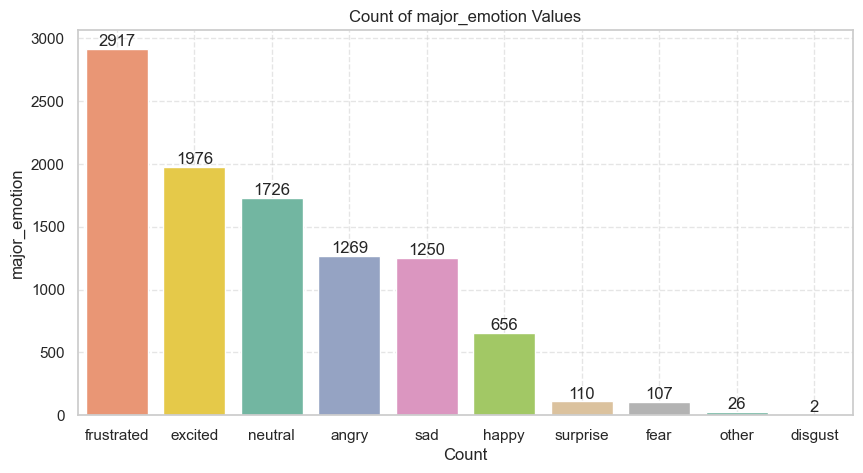

In [11]:

plot_column_values(df, "major_emotion")

`frustrated` (2,917, 29.1%) is the single largest class in the raw corpus. `excited` (1,976, 19.7%) maps to `happy`. Together they represent nearly half the data — both are retained in the 5-class mapping.

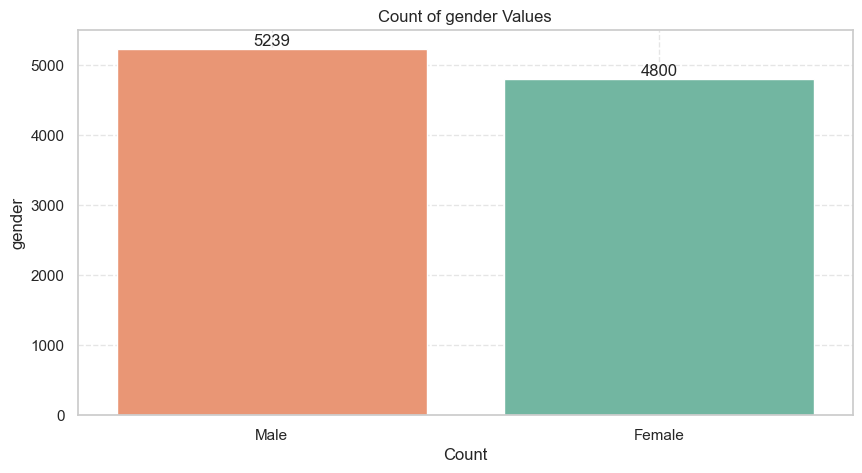

In [12]:
plot_column_values(df, "gender")

Near-balanced by design — IEMOCAP pairs exactly one male and one female actor per session. The 439-utterance gap (Male 52.2% / Female 47.8%) reflects natural variation in turn length, not a sampling bias.

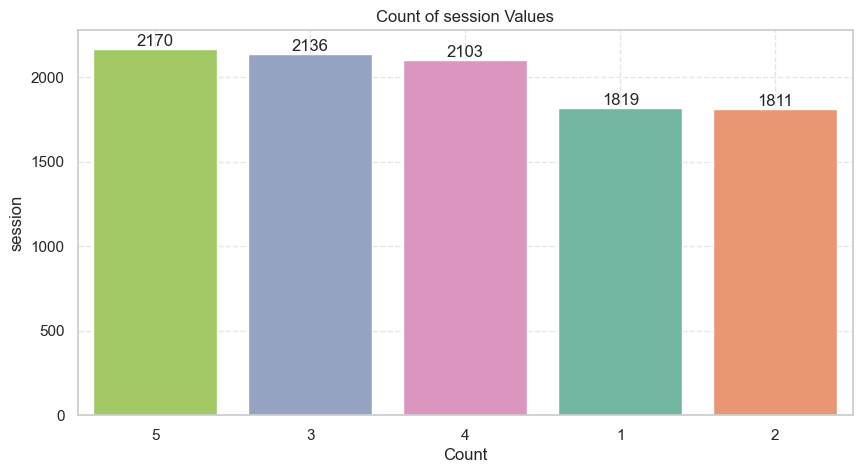

In [13]:
plot_column_values(df, "session")

Session sizes range from 1,811 to 2,170 — close enough that each LOSO fold trains on roughly the same amount of data. Sessions 3–5 are slightly larger than 1–2 but the difference is not large enough to create a meaningful train-set size disparity across folds.

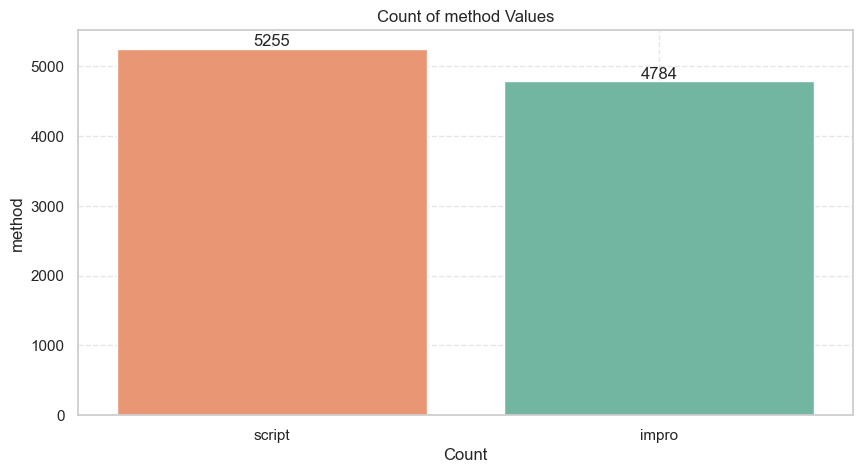

In [14]:
plot_column_values(df, "method")

#### Distribution Findings

**`major_emotion` — 10 classes, 10,039 utterances total**

| Emotion | Count | % | Fate in 5-class mapping |
|---|---|---|---|
| frustrated | 2,917 | 29.1% | **Kept** — own class; too large to drop |
| excited | 1,976 | 19.7% | **Merged → happy** — acoustically indistinguishable |
| neutral | 1,726 | 17.2% | Kept |
| angry | 1,269 | 12.6% | Kept |
| sad | 1,250 | 12.5% | Kept |
| happy | 656 | 6.5% | Kept — merges with excited to form 2,632 |
| surprise | 110 | 1.1% | Dropped — too few samples |
| fear | 107 | 1.1% | Dropped — too few samples |
| other | 26 | 0.3% | Dropped — no meaningful label |
| disgust | 2 | 0.02% | Dropped — only 2 utterances |

After the 5-class mapping, **9,794 utterances** are retained (only 2.4% dropped — minority labels only).

---

**`gender` — 2 classes, near-balanced by design**

| Gender | Count | % |
|---|---|---|
| Male | 5,239 | 52.2% |
| Female | 4,800 | 47.8% |

IEMOCAP pairs one male and one female actor per session, so balance is structural.

---

**`session` — 5 sessions, broadly even in size**

| Session | Count | % |
|---|---|---|
| 1 | 1,819 | 18.1% |
| 2 | 1,811 | 18.0% |
| 3 | 2,136 | 21.3% |
| 4 | 2,103 | 20.9% |
| 5 | 2,170 | 21.6% |

Sessions 3–5 are slightly larger, but all five LOSO folds train on ~80% of data — no severe imbalance.

---

**`method` — 2 types, roughly balanced**

| Method | Count | % |
|---|---|---|
| script | 5,255 | 52.4% |
| impro | 4,784 | 47.6% |

`impro` produces more angry/frustrated/sad; `script` produces more neutral/happy. Method is a potential confounder.

---
## Step 5 — Label Mapping (5-class)

Per the professor's feedback, `frustrated` is **retained** as its own class — it represents 29% of the corpus (2,917 utterances) and is too large to discard. This project uses a **5-class** setup:

| `major_emotion` | 5-class label |
|---|---|
| angry | angry |
| frustrated | frustrated |
| happy | happy |
| excited | happy (merged) |
| neutral | neutral |
| sad | sad |
| disgust / fear / surprise / other | **dropped** (too few samples) |

In [15]:
# 5-class label mapping. 'excited' is merged into 'happy' (acoustically inseparable).
# 'frustrated' is now kept as its own class — too large to drop (29% of corpus).
# Minority labels (disgust, fear, surprise, other, xxx) are dropped — too few samples.
LABEL_MAP = {
    'angry'     : 'angry',
    'frustrated': 'frustrated',
    'happy'     : 'happy',
    'excited'   : 'happy',       # merged — heavily overlaps with happy
    'neutral'   : 'neutral',
    'sad'       : 'sad',
}

df_raw = df.copy()

df = df[df['major_emotion'].isin(LABEL_MAP)].copy()
df['emotion'] = df['major_emotion'].map(LABEL_MAP)

dropped = len(df_raw) - len(df)
print(f"Raw rows  : {len(df_raw):,}")
print(f"Dropped   : {dropped:,} ({dropped/len(df_raw)*100:.1f}%)  ← minority labels only")
print(f"Retained  : {len(df):,}")
print()
print("5-class distribution:")
for cls, cnt in df['emotion'].value_counts().items():
    print(f"  {cls:<12} {cnt:>5}  ({cnt/len(df)*100:.1f}%)")

# Define palette here so it's available for all subsequent plots
EMOTION_PALETTE = {
    'angry'     : '#d62728',
    'frustrated': '#ff7f0e',
    'happy'     : '#2ca02c',
    'neutral'   : '#1f77b4',
    'sad'       : '#9467bd',
}

Raw rows  : 10,039
Dropped   : 245 (2.4%)  ← minority labels only
Retained  : 9,794

5-class distribution:
  frustrated    2917  (29.8%)
  happy         2632  (26.9%)
  neutral       1726  (17.6%)
  angry         1269  (13.0%)
  sad           1250  (12.8%)


### Why 5 classes?

#### The IEMOCAP corpus

IEMOCAP (Interactive Emotional Dyadic Motion Capture) was introduced by **Busso et al. (2008)** at USC. It contains **10,039 utterances** from 10 actors across 5 sessions. Utterances were elicited through scripted scenarios or improvised emotional dialogues and labelled by multiple annotators.

---

#### Label decisions

**1. Retain `frustrated` as its own class**  
Frustrated is the single largest category in the raw corpus (2,917 utterances, 29%). Dropping it wastes almost a third of the data and introduces selection bias. While frustrated shares some acoustic properties with angry and neutral, it has a distinct perceptual profile — characterised by slower tempo, pressed voice quality, and broad pitch variation — and its own annotator agreement. It is retained as the 5th class.

**2. Merge `excited` → `happy`**  
Excited and happy are acoustically near-identical — both exhibit high pitch, high energy, and fast speaking rate. The soft-label data confirms annotators split their votes almost evenly between the two. Merging reduces label noise without losing data.

**3. Drop minority labels**  
Disgust (2), fear (107), surprise (110), and other (26) are dropped — no classifier can learn a meaningful boundary from fewer than ~110 examples in a highly imbalanced corpus.

---

#### Summary

| Decision | Labels | Count | Reason |
|---|---|---|---|
| **Keep** | angry, frustrated, happy, neutral, sad | — | All major classes with sufficient samples |
| **Merge** excited → happy | excited | 1,976 | Acoustically identical; annotators split evenly |
| **Drop** | disgust, fear, surprise, other | 2–110 each | Too few samples for a reliable class boundary |

**Result:** only 245 rows dropped (2.4%) — **9,794 utterances retained**.

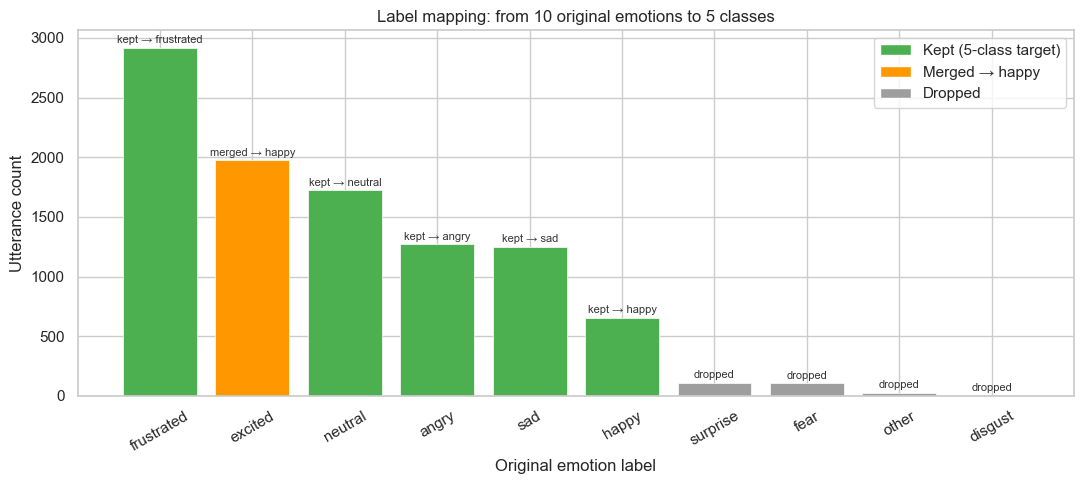

In [16]:
DECISION_COLORS = {
    'neutral'   : '#4CAF50',   # kept → neutral
    'angry'     : '#4CAF50',   # kept → angry
    'sad'       : '#4CAF50',   # kept → sad
    'happy'     : '#4CAF50',   # kept → happy
    'frustrated': '#4CAF50',   # kept → frustrated (5th class)
    'excited'   : '#FF9800',   # merged → happy
    'disgust'   : '#9E9E9E',   # dropped
    'fear'      : '#9E9E9E',   # dropped
    'surprise'  : '#9E9E9E',   # dropped
    'other'     : '#9E9E9E',   # dropped
}

DECISION_LABELS = {
    'neutral'   : 'kept → neutral',
    'angry'     : 'kept → angry',
    'sad'       : 'kept → sad',
    'happy'     : 'kept → happy',
    'frustrated': 'kept → frustrated',
    'excited'   : 'merged → happy',
    'disgust'   : 'dropped',
    'fear'      : 'dropped',
    'surprise'  : 'dropped',
    'other'     : 'dropped',
}

counts = df_raw['major_emotion'].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(
    counts.index,
    counts.values,
    color=[DECISION_COLORS[e] for e in counts.index],
    edgecolor='white', linewidth=0.5
)

for bar, label in zip(bars, [DECISION_LABELS[e] for e in counts.index]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        label, ha='center', va='bottom', fontsize=8, color='#333333'
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label='Kept (5-class target)'),
    Patch(facecolor='#FF9800', label='Merged → happy'),
    Patch(facecolor='#9E9E9E', label='Dropped'),
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_title('Label mapping: from 10 original emotions to 5 classes')
ax.set_xlabel('Original emotion label')
ax.set_ylabel('Utterance count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Only the four minority labels (disgust, fear, surprise, other — 245 utterances total, 2.4%) are dropped. `frustrated` is retained as the 5th class. `excited` is merged into `happy`, preserving all 1,976 excited utterances rather than discarding them.

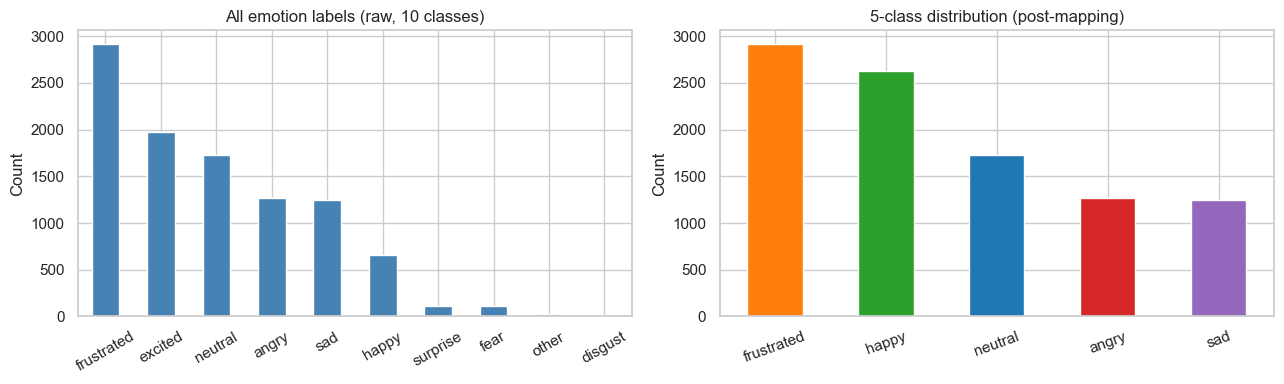

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_raw['major_emotion'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('All emotion labels (raw, 10 classes)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

df['emotion'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=[EMOTION_PALETTE[e] for e in df['emotion'].value_counts().index]
)
axes[1].set_title('5-class distribution (post-mapping)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

---
## Label Justification: Feature-Space Evidence

Two complementary views confirm why `excited → happy` can be safely merged, and why `frustrated` occupies a distinct enough position to warrant its own class.

**Why merge `excited → happy`**
- Their EmoAct and EmoVal distributions nearly coincide — they occupy the same region of emotion space
- Annotators who labelled excited speech gave nearly as much probability mass to the `happy` soft label as to `excited`, and vice versa

**Why keep `frustrated` as its own class**
- In both EmoAct and EmoVal, frustrated sits between angry and neutral — it has no clean home in either
- But its VAD centroid (moderate arousal, low-to-mid valence) is distinct from any single class
- The corpus is large enough (2,917 samples) that the classifier can learn a boundary

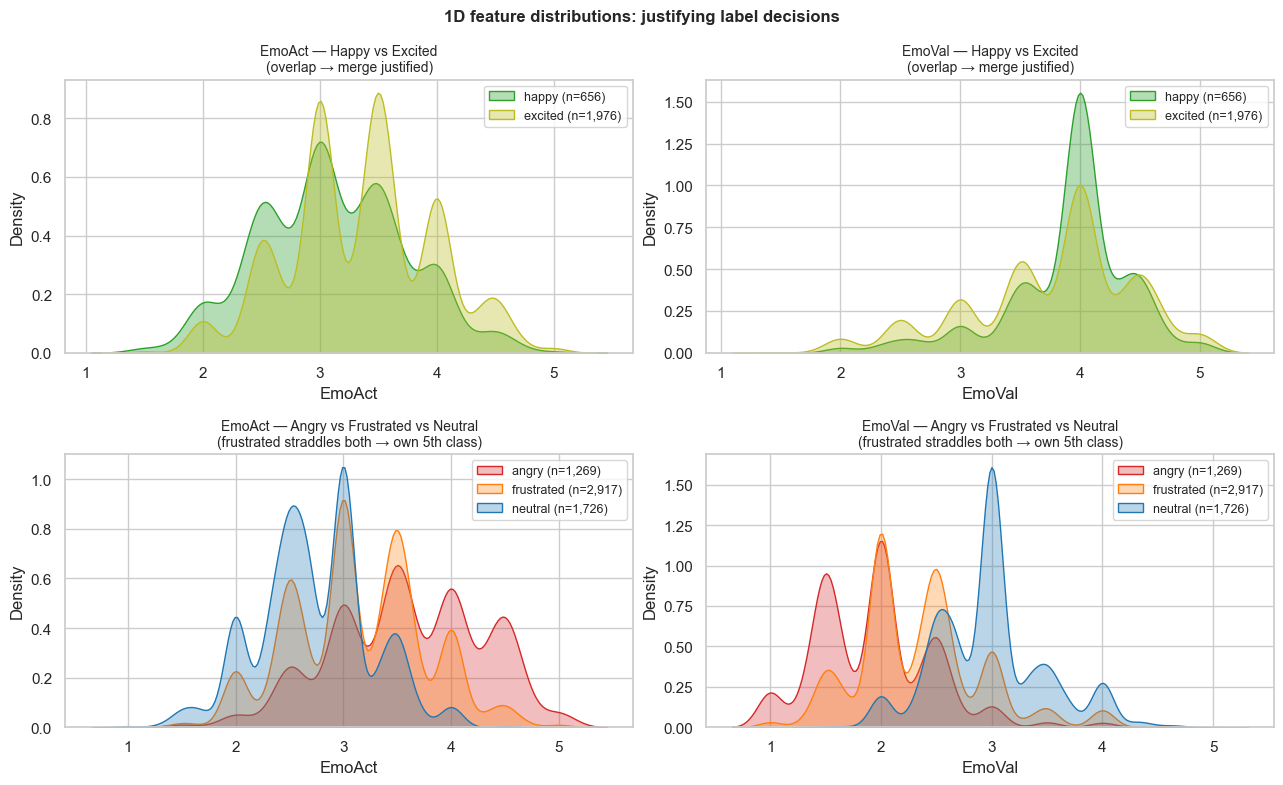

In [18]:
# ── Plot 1: 1D distribution comparison on EmoAct and EmoVal ──────────────────
# [top row]    EmoAct/EmoVal for happy vs excited → nearly identical → merge safe
# [bottom row] EmoAct/EmoVal for angry/frustrated/neutral → frustrated between them
#              → cannot merge cleanly into either → must be its own class

PALETTE = {
    'happy'     : '#2ca02c',
    'excited'   : '#bcbd22',
    'angry'     : '#d62728',
    'frustrated': '#ff7f0e',
    'neutral'   : '#1f77b4',
    'sad'       : '#9467bd',
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

merge_classes  = ['happy', 'excited']
border_classes = ['angry', 'frustrated', 'neutral']   # frustrated straddles the boundary

for col_idx, vad_col in enumerate(['EmoAct', 'EmoVal']):
    ax = axes[0][col_idx]
    for cls in merge_classes:
        subset = df_raw[df_raw['major_emotion'] == cls]
        sns.kdeplot(subset[vad_col], ax=ax, label=f'{cls} (n={len(subset):,})',
                    color=PALETTE[cls], fill=True, alpha=0.35, bw_adjust=0.9)
    ax.set_title(f'{vad_col} — Happy vs Excited\n(overlap → merge justified)', fontsize=10)
    ax.set_xlabel(vad_col); ax.legend(fontsize=9)

    ax = axes[1][col_idx]
    for cls in border_classes:
        subset = df_raw[df_raw['major_emotion'] == cls]
        sns.kdeplot(subset[vad_col], ax=ax, label=f'{cls} (n={len(subset):,})',
                    color=PALETTE[cls], fill=True, alpha=0.30, bw_adjust=0.9)
    ax.set_title(f'{vad_col} — Angry vs Frustrated vs Neutral\n'
                 f'(frustrated straddles both → own 5th class)', fontsize=10)
    ax.set_xlabel(vad_col); ax.legend(fontsize=9)

plt.suptitle('1D feature distributions: justifying label decisions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Top row:** the `happy` and `excited` curves nearly stack on both EmoAct and EmoVal — they occupy the same region of emotion space, making the merge acoustically and perceptually justified. **Bottom row:** `frustrated` sits between `angry` and `neutral` on EmoAct and spans a wide range on EmoVal — it has no clean home in either class, which is exactly why it is kept as its own 5th class rather than merged.

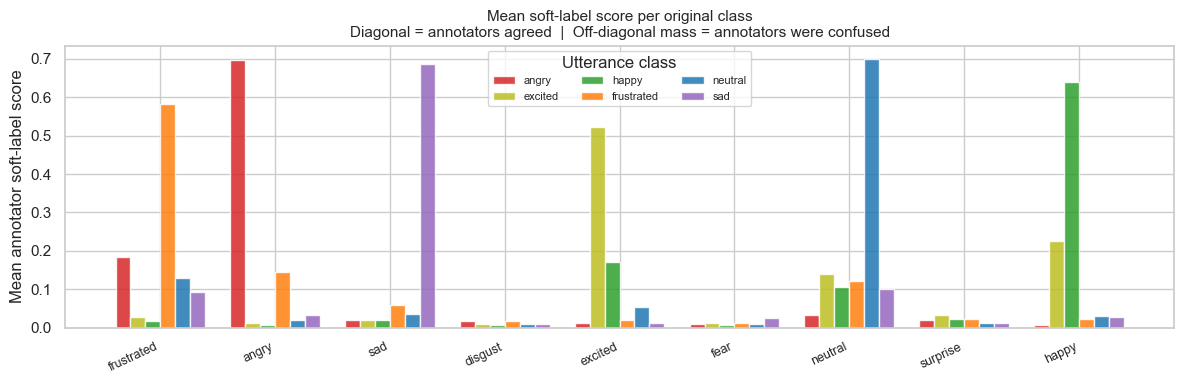

In [19]:
# ── Plot 2: Annotator soft-label "leakage" ───────────────────────────────────
# For each original emotion class, show the MEAN soft label score across all
# utterances in that class. The diagonal (class scores highest on its own column)
# means annotators agreed. Off-diagonal mass means annotators were confused.
#
# Key things to read:
#   excited row: high score on BOTH 'excited' and 'happy' columns
#                → annotators regularly confused the two → merge removes the noise
#
#   frustrated row: probability spread across 'angry', 'frustrated', 'neutral', 'sad'
#                   → no dominant neighbour → cannot cleanly merge into any one class
#                   → dropping it is safer than adding noise to another class

soft_cols   = ['frustrated','angry','sad','disgust','excited','fear','neutral','surprise','happy']
focus_cls   = ['angry', 'excited', 'happy', 'frustrated', 'neutral', 'sad']

soft_means = (
    df_raw[df_raw['major_emotion'].isin(focus_cls)]
    .groupby('major_emotion')[soft_cols]
    .mean()
    .loc[focus_cls]          # keep display order intentional
)

fig, ax = plt.subplots(figsize=(12, 4))
x      = np.arange(len(soft_cols))
width  = 0.13
colors = [PALETTE[c] for c in focus_cls]

for i, (cls, row) in enumerate(soft_means.iterrows()):
    ax.bar(x + i * width, row.values, width, label=cls, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * (len(focus_cls) - 1) / 2)
ax.set_xticklabels(soft_cols, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Mean annotator soft-label score')
ax.set_title(
    'Mean soft-label score per original class\n'
    'Diagonal = annotators agreed  |  Off-diagonal mass = annotators were confused',
    fontsize=11
)
ax.legend(title='Utterance class', fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

`excited` shows nearly equal bars on the `excited` and `happy` columns — annotators split their votes almost evenly between the two, confirming the merge is safe. `frustrated` spreads probability across `angry`, `frustrated`, `neutral`, and `sad` with no dominant neighbour — confirming it cannot be cleanly absorbed into any single class, which is why it is kept as its own 5th class.

---
## Step 6 — Audio Analysis

IEMOCAP is fundamentally an **audio corpus** — every label was assigned by listening to a recording. This section loads the raw speech signals, applies time-domain and frequency-domain analysis, extracts a full acoustic feature set, and visualises how those features differ across emotion classes.

Analysis flow:
- **6a** Waveform + RMS energy envelope  
- **6b** FFT power spectrum  
- **6c** Mel-spectrogram (STFT-based)  
- **6d** MFCC per utterance + per-class average  
- **6e** Spectral features (ZCR, centroid, rolloff, bandwidth)  
- **6f** Full feature extraction → model-ready DataFrame

In [20]:
import librosa
import librosa.display

# The 5-class mapping is already applied (Step 5), so we use df['emotion'] directly.
AUDIO_EMOTIONS = ['angry', 'frustrated', 'neutral', 'sad', 'happy']

AUDIO_PALETTE = {
    'angry'     : '#d62728',
    'frustrated': '#ff7f0e',
    'neutral'   : '#1f77b4',
    'sad'       : '#9467bd',
    'happy'     : '#2ca02c',
}

# Pick one representative utterance per class (fixed seed for reproducibility).
# df.index aligns with ds indices because df was created via ds.to_pandas() with no row drops yet.
rng = np.random.default_rng(RANDOM_SEED)
SAMPLES = {}
for emo in AUDIO_EMOTIONS:
    candidate_idxs = df[df['emotion'] == emo].index.tolist()
    chosen = int(rng.choice(candidate_idxs))
    audio_data = ds[chosen]['audio']
    SAMPLES[emo] = {
        'array': np.array(audio_data['array'], dtype=np.float32),
        'sr'   : audio_data['sampling_rate'],
        'file' : df.loc[chosen, 'file'],
        'ds_idx': chosen,
    }

for emo, s in SAMPLES.items():
    dur = len(s['array']) / s['sr']
    print(f"{emo:<12} sr={s['sr']} Hz  dur={dur:.2f}s  file={s['file']}")

angry        sr=16000 Hz  dur=2.33s  file=Ses01F_script03_2_M030.wav
frustrated   sr=16000 Hz  dur=5.38s  file=Ses04M_script02_2_M015.wav
neutral      sr=16000 Hz  dur=3.35s  file=Ses04F_impro07_M013.wav
sad          sr=16000 Hz  dur=4.07s  file=Ses03F_script01_3_F008.wav
happy        sr=16000 Hz  dur=8.07s  file=Ses03F_script02_2_F043.wav


### 6a. Waveform + RMS energy envelope

The amplitude waveform shows how loudness evolves over time. The RMS energy envelope (smoothed frame-by-frame energy) highlights voiced segments and pauses — angry speech tends to have bursts of high energy; sad speech is flatter and quieter.

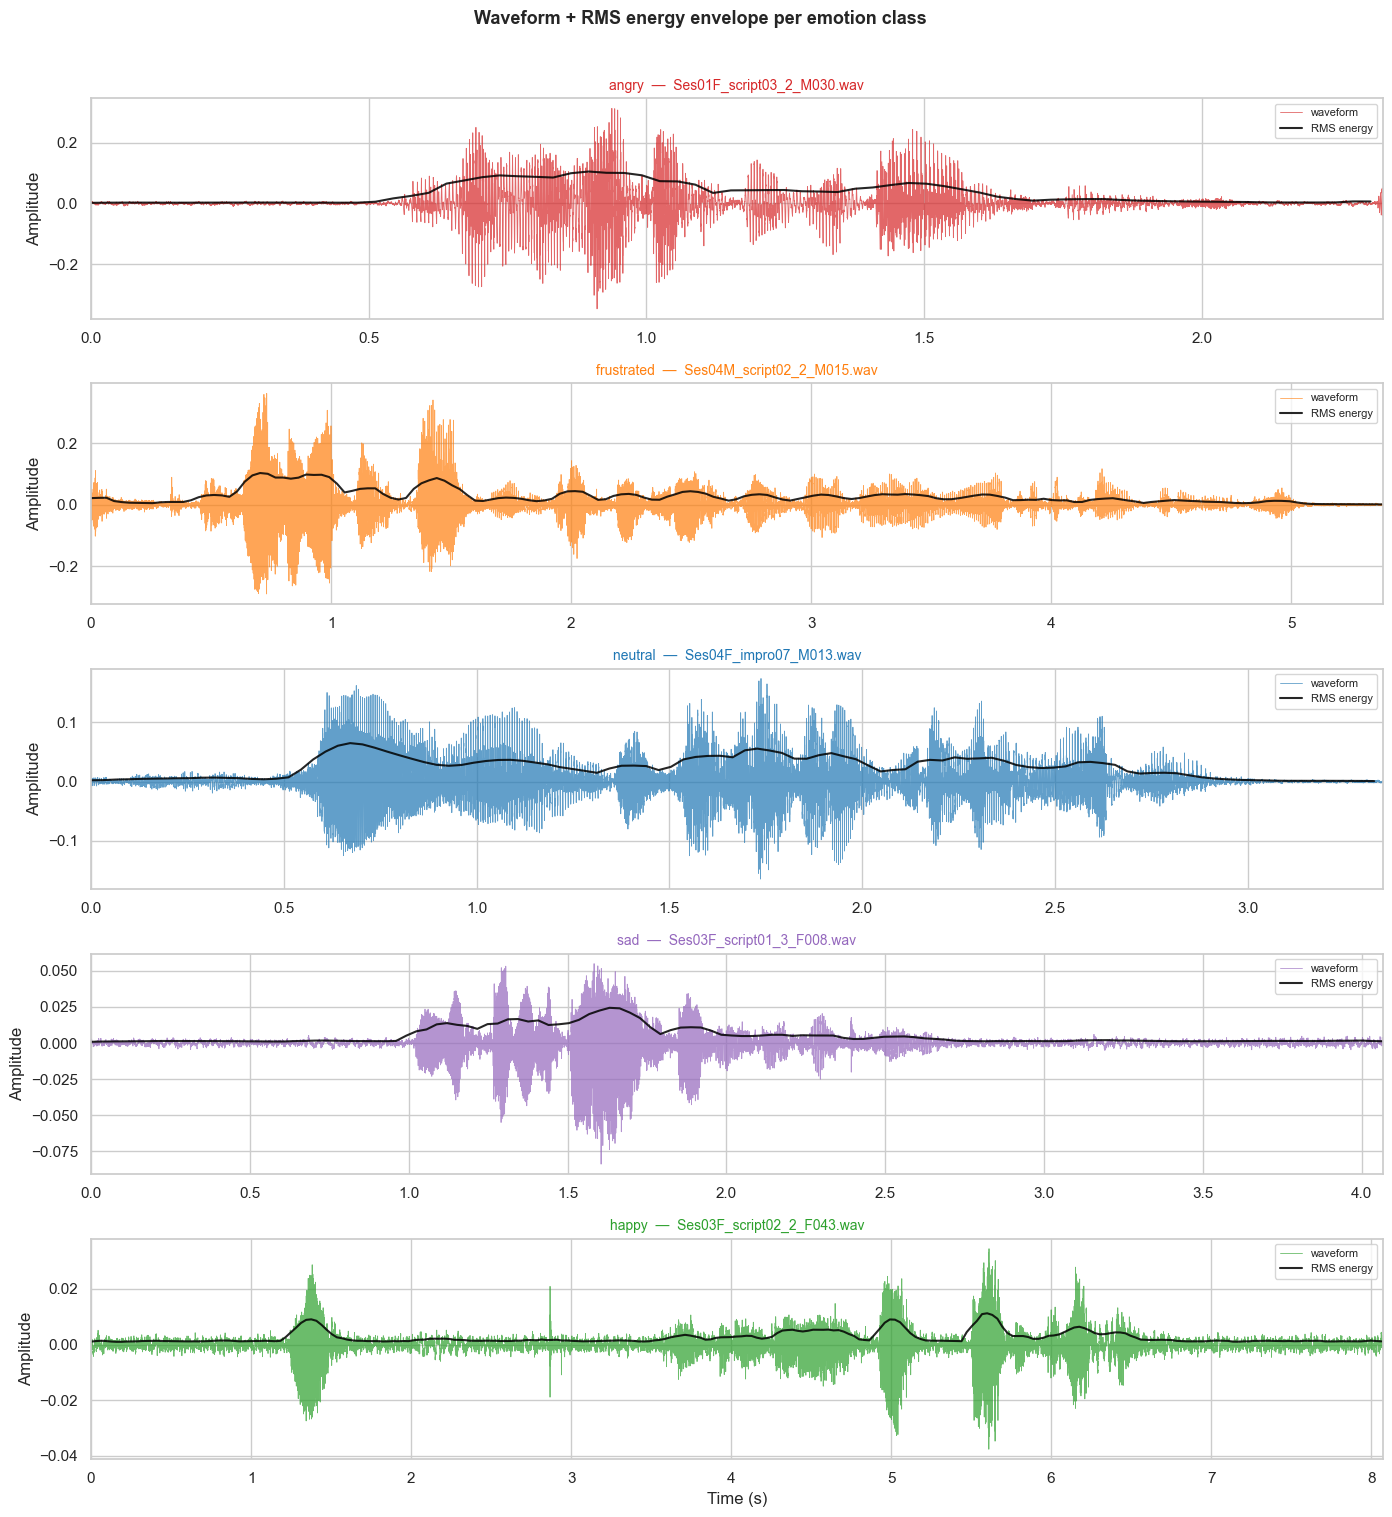

In [21]:
fig, axes = plt.subplots(len(AUDIO_EMOTIONS), 1, figsize=(14, 3 * len(AUDIO_EMOTIONS)), sharex=False)

for ax, emo in zip(axes, AUDIO_EMOTIONS):
    s = SAMPLES[emo]
    y, sr = s['array'], s['sr']
    t = np.linspace(0, len(y) / sr, num=len(y))

    # Raw waveform
    ax.plot(t, y, color=AUDIO_PALETTE[emo], linewidth=0.6, alpha=0.7, label='waveform')

    # RMS energy envelope (frame_length=2048, hop_length=512)
    rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
    t_rms = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=512)
    ax.plot(t_rms, rms, color='black', linewidth=1.5, alpha=0.85, label='RMS energy')

    ax.set_title(f'{emo}  —  {s["file"]}', fontsize=10, color=AUDIO_PALETTE[emo])
    ax.set_ylabel('Amplitude')
    ax.set_xlim(0, t[-1])
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Waveform + RMS energy envelope per emotion class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Waveform observations:**

| Emotion | Duration | Amplitude profile | RMS pattern |
|---|---|---|---|
| **angry** | 2.33 s | High-amplitude bursts, sharp peaks | Spiky -- energy comes in sudden high-intensity bursts |
| **frustrated** | 5.38 s | Moderate amplitude, sustained | Steady rises -- prolonged and controlled, not explosive |
| **neutral** | 3.35 s | Low, even amplitude | Flat RMS -- minimal dynamic variation |
| **sad** | 4.07 s | Very low amplitude throughout | Near-flat envelope -- quiet, subdued, few energy peaks |
| **happy** | 8.07 s | Variable amplitude, sustained | Broad envelope -- expressive with sustained energy |

**Conclusions:** Emotional arousal is immediately visible in the amplitude envelope. The angry sample shows the starkest pattern -- the RMS envelope spikes sharply in short bursts consistent with explosive, staccato delivery. Sad shows the opposite: a uniformly low, flat envelope. Frustrated sits in between -- higher and more variable energy than neutral/sad, but without sharp spikes. Happy is the longest utterance (8s) with a broad, sustained envelope reflecting expressive speech. The pre-extracted `rms` and `relative_db` scalars summarise these envelope shapes as single numbers; the waveform reveals the temporal dynamics those scalars discard.

### 6b. FFT — Power Spectrum

The Fast Fourier Transform decomposes each utterance into its constituent frequencies. Speech energy concentrates in the 0–4 kHz band (fundamental frequency + first few formants). High-arousal emotions (angry, frustrated) tend to push more energy into mid-to-high frequencies; sad speech concentrates energy at lower frequencies.

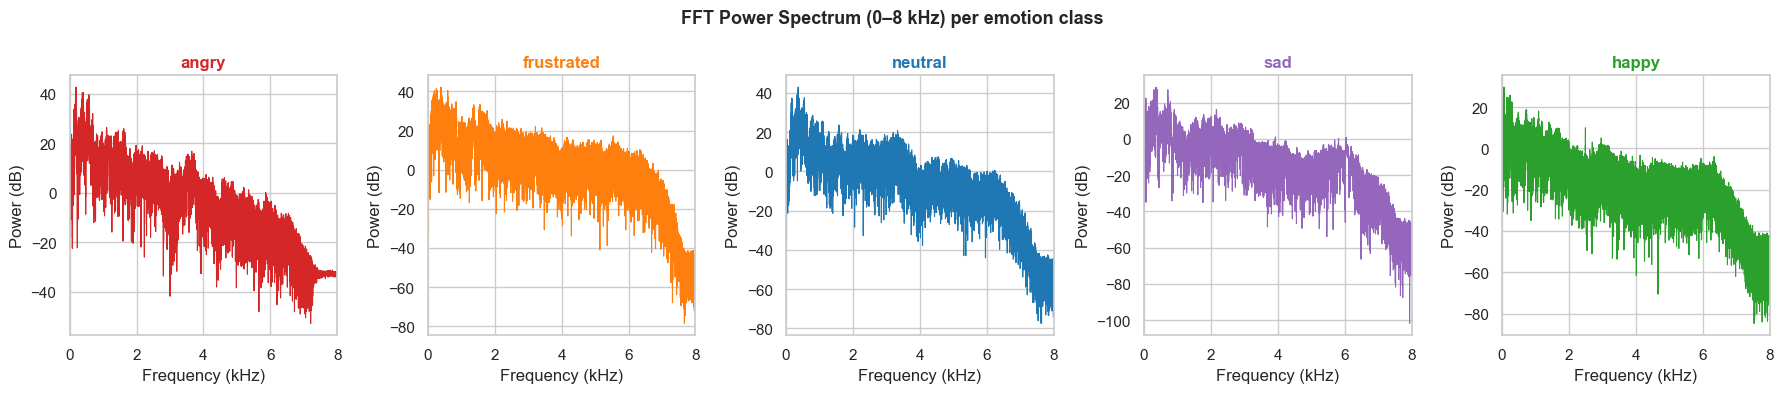

In [22]:
fig, axes = plt.subplots(1, len(AUDIO_EMOTIONS), figsize=(18, 4), sharey=False)

for ax, emo in zip(axes, AUDIO_EMOTIONS):
    s = SAMPLES[emo]
    y, sr = s['array'], s['sr']

    # Real FFT — output length is N//2 + 1 (positive frequencies only)
    N = len(y)
    fft_mag = np.abs(np.fft.rfft(y))
    freqs   = np.fft.rfftfreq(N, d=1.0 / sr)

    # Convert to dB power spectrum and cap display at 8 kHz (most speech energy is below)
    power_db = 20 * np.log10(fft_mag + 1e-8)
    mask = freqs <= 8000

    ax.plot(freqs[mask] / 1000, power_db[mask], color=AUDIO_PALETTE[emo], linewidth=0.8)
    ax.set_title(emo, color=AUDIO_PALETTE[emo], fontweight='bold')
    ax.set_xlabel('Frequency (kHz)')
    ax.set_ylabel('Power (dB)')
    ax.set_xlim(0, 8)

plt.suptitle('FFT Power Spectrum (0–8 kHz) per emotion class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**FFT Power Spectrum observations:**

The x-axis spans 0--8 kHz; the y-axis is dB power. Two things matter: the **starting level** (absolute power at 0 Hz) and the **spectral slope** (how steeply energy drops with frequency).

**Starting power (0 Hz peak):**
- Angry and frustrated both peak at ~+40 dB -- clearly the loudest utterances.
- Happy and sad peak at ~+25--30 dB -- moderate level.
- Neutral is the quietest, starting at only ~+15 dB.

**Spectral slope (drop from 0 to 8 kHz):**
- **Angry**: the flattest slope -- drops only ~70 dB from 0 to 8 kHz. Energy is genuinely distributed across the full spectrum, confirming the broad, bright character seen in the waveform.
- **Frustrated and happy**: both drop ~100--105 dB -- significantly steeper than angry. Despite starting at high power, they shed energy quickly above 2 kHz. These two spectra are actually the most similar to each other in shape.
- **Neutral**: drops ~85 dB but starts low, so the absolute high-frequency energy is the lowest of all five.
- **Sad**: the steepest slope -- drops ~125 dB. All energy is concentrated in the lowest frequency band (< 1 kHz), with almost nothing above 3 kHz.

**Key corrections from earlier claim:** Happy is NOT similar to angry. Happy has a steep slope; angry has a flat one. The correct pairing by spectral shape is angry (flat) vs. everyone else (steep), and within the "steep" group, frustrated and happy are most alike.

**Conclusion:** The spectral slope cleanly separates high-arousal (angry = flat/broad) from all other classes. Sad has the steepest drop and the most frequency-limited spectrum. Frustrated and happy are nearly indistinguishable by slope alone -- another signal that these two classes are spectrally similar.

### 6c. Mel-Spectrogram

The mel-spectrogram applies the Short-Time Fourier Transform (STFT) across sliding windows, then warps the frequency axis to the mel scale (which matches human auditory perception — finer resolution at low frequencies, coarser at high). Each column is one time frame; each row is one mel frequency band. Brighter = more energy.

Two views:
1. **Single sample** — shows the time-frequency structure of one utterance per emotion
2. **Per-class average** — mean mel-spectrogram over 50 random utterances, smoothing out speaker-specific variation to reveal emotion-level patterns

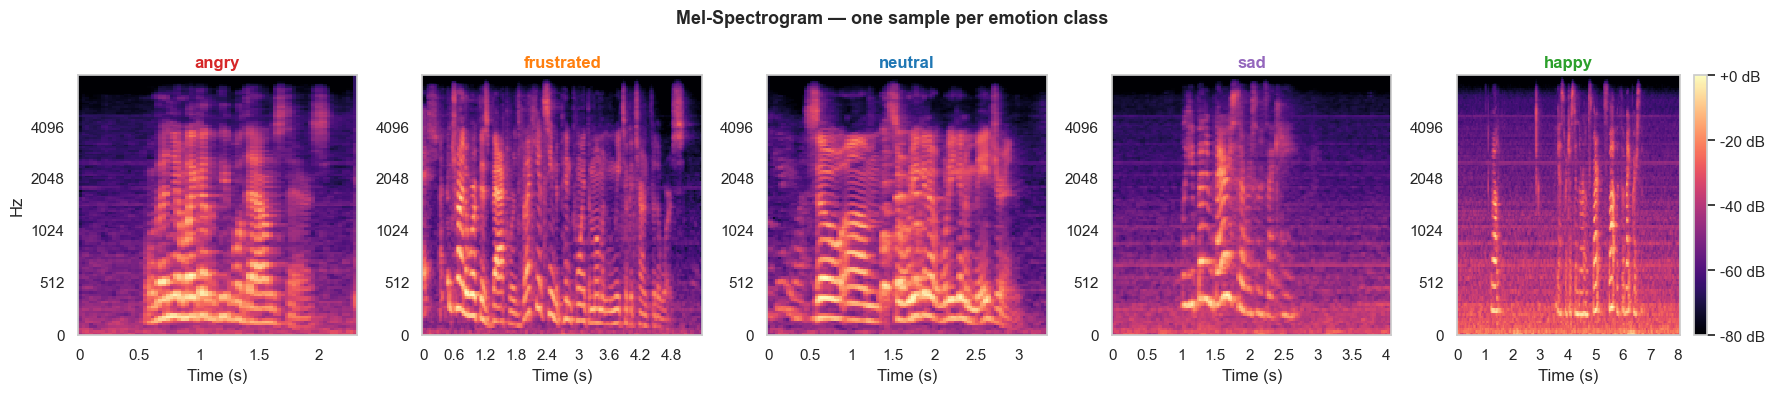

In [23]:
# ── Single-sample mel-spectrograms ───────────────────────────────────────────
fig, axes = plt.subplots(1, len(AUDIO_EMOTIONS), figsize=(18, 4))

for ax, emo in zip(axes, AUDIO_EMOTIONS):
    s = SAMPLES[emo]
    y, sr = s['array'], s['sr']

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_db = librosa.power_to_db(S, ref=np.max)

    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel',
                                   fmax=8000, ax=ax, cmap='magma')
    ax.set_title(emo, color=AUDIO_PALETTE[emo], fontweight='bold')
    ax.set_xlabel('Time (s)')
    if ax != axes[0]:
        ax.set_ylabel('')

fig.colorbar(img, ax=axes[-1], format='%+2.0f dB')
plt.suptitle('Mel-Spectrogram — one sample per emotion class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Single-sample mel-spectrogram observations:**

- **Angry (2.33 s)**: bright colours across the entire mel band, including the upper half (high mel frequencies = 2--8 kHz). Short, intense: the bright regions span almost the full duration with no extended silences. The harmonics (horizontal bright bands) are wide-spaced, reflecting a high pitch.
- **Frustrated (5.38 s)**: moderate brightness, spread over a longer duration. The upper mel bands are dimmer than angry but brighter than neutral. Notable pauses visible as vertical dark bands -- frustrated speech includes strategic pauses and restarts.
- **Neutral (3.35 s)**: concentrated brightness in the lower mel bands (0--1 kHz), with the upper half much darker. Clean harmonic structure with evenly spaced horizontal bands. Minimal energy above the 3rd or 4th harmonic.
- **Sad (4.07 s)**: similar to neutral but darker overall -- the energy is more concentrated in a narrow low-frequency band. The periodicity (horizontal banding) is visible but dim.
- **Happy (8.07 s)**: the longest and most varied spectrogram. Bright mid-band energy (1--3 kHz) in bursts, with several distinct speech segments separated by pauses. The harmonic structure is complex, reflecting the range of intonation in happy/excited speech.

**Conclusion:** The mel-spectrogram makes the emotional content visually obvious. Bright upper bands = high arousal. Dark upper bands = low arousal. Duration and pause structure also carry information: frustrated speech is long and pause-heavy; angry speech is short and dense.

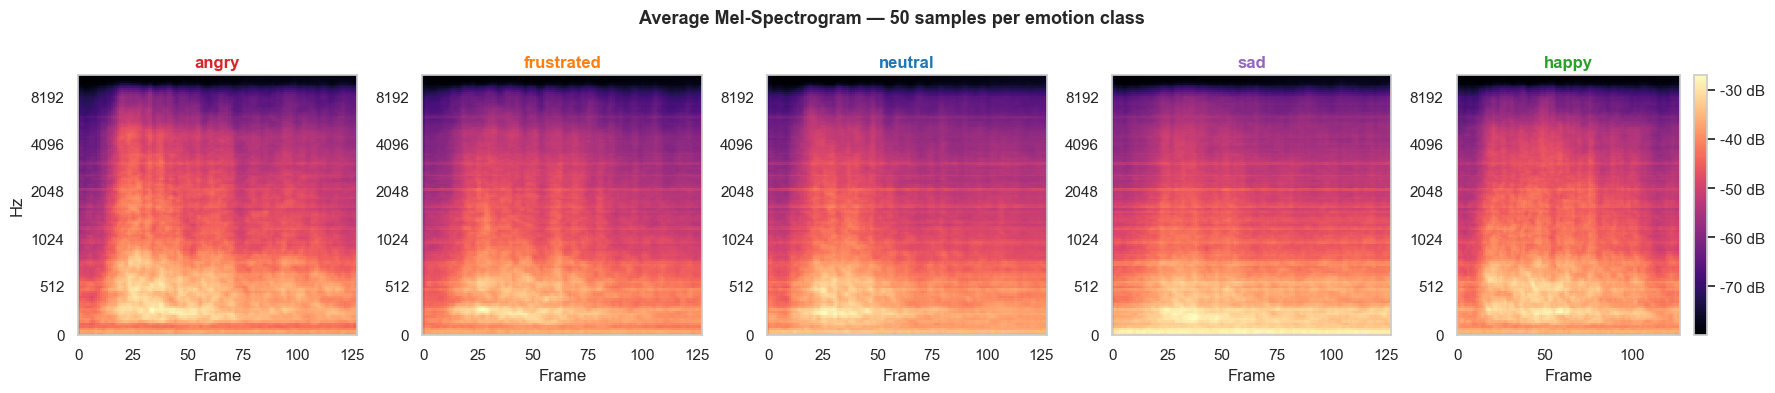

In [24]:
# ── Per-class average mel-spectrogram (50 samples per emotion) ───────────────
N_AVG = 50
N_MELS = 128
# Fixed number of mel frames to align spectrograms of different-length utterances
TARGET_FRAMES = 128

avg_specs = {}
for emo in AUDIO_EMOTIONS:
    idxs = df[df['emotion'] == emo].index.tolist()
    chosen = rng.choice(idxs, size=min(N_AVG, len(idxs)), replace=False)
    specs = []
    for idx in chosen:
        audio_data = ds[int(idx)]['audio']
        y  = np.array(audio_data['array'], dtype=np.float32)
        sr = audio_data['sampling_rate']
        S  = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=8000)
        S_db = librosa.power_to_db(S, ref=np.max)
        # Resize time axis to TARGET_FRAMES so all spectrograms can be averaged
        if S_db.shape[1] >= TARGET_FRAMES:
            S_db = S_db[:, :TARGET_FRAMES]
        else:
            pad = TARGET_FRAMES - S_db.shape[1]
            S_db = np.pad(S_db, ((0, 0), (0, pad)), mode='edge')
        specs.append(S_db)
    avg_specs[emo] = np.mean(specs, axis=0)

fig, axes = plt.subplots(1, len(AUDIO_EMOTIONS), figsize=(18, 4))
for ax, emo in zip(axes, AUDIO_EMOTIONS):
    img = librosa.display.specshow(avg_specs[emo], x_axis='frames', y_axis='mel',
                                   sr=22050, ax=ax, cmap='magma')
    ax.set_title(emo, color=AUDIO_PALETTE[emo], fontweight='bold')
    ax.set_xlabel('Frame')
    if ax != axes[0]:
        ax.set_ylabel('')

fig.colorbar(img, ax=axes[-1], format='%+2.0f dB')
plt.suptitle(f'Average Mel-Spectrogram — {N_AVG} samples per emotion class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Per-class average mel-spectrogram observations** (mean over 50 utterances per class):

Averaging over 50 utterances smooths out speaker-specific and content-specific variation, revealing the systematic emotion-level patterns:

- **Angry**: the brightest class in the upper mel bands (rows 60--128, corresponding to ~1--8 kHz). The entire spectrogram is uniformly bright with no clear pause structure -- angry speech is dense throughout.
- **Frustrated**: second brightest overall. The average is brighter than neutral/sad but darker than angry in the upper bands. The time axis shows slightly uneven brightness, consistent with the pause-and-resume pattern noted in the single sample.
- **Neutral**: the most spectrally narrow -- brightness concentrates in the bottom 40 mel bands (~0--500 Hz). A clean, bright harmonic band at the very bottom (fundamental frequency region) with rapid falloff above it.
- **Sad**: the darkest average spectrogram. Very similar to neutral but with lower overall brightness even in the low bands -- consistent with sad's uniformly low energy. The low-frequency harmonic band is present but dim.
- **Happy**: similar brightness to frustrated overall, with a notable concentration in the mid-mel range (mel bands 30--80, ~300--2000 Hz). Bright mid-band energy reflects the mixed vowel content in excited/happy speech.

**Key takeaway**: The average spectrogram cleanly shows the arousal axis. Sorting by brightness from top to bottom gives: angry > happy ≈ frustrated > neutral > sad. This ordering matches the MFCC-1 energy values (-326, -366, -384, -404, -455) computed over the full corpus in Section 6f.

### 6d. MFCC — Mel-Frequency Cepstral Coefficients

MFCCs are the standard compact representation of vocal tract shape derived from the mel-spectrogram. 13 coefficients capture the bulk of the speech timbre information:
- **MFCC-1** tracks overall energy (loudness)  
- **MFCC-2 to 4** capture broad spectral shape (related to vowel quality)  
- **MFCC-5+** capture fine spectral detail (consonants, articulation)

We show the MFCC matrix for one sample per class, then the per-class **mean MFCC vector** aggregated over the full corpus — the mean compresses the time axis and gives a single profile per emotion.

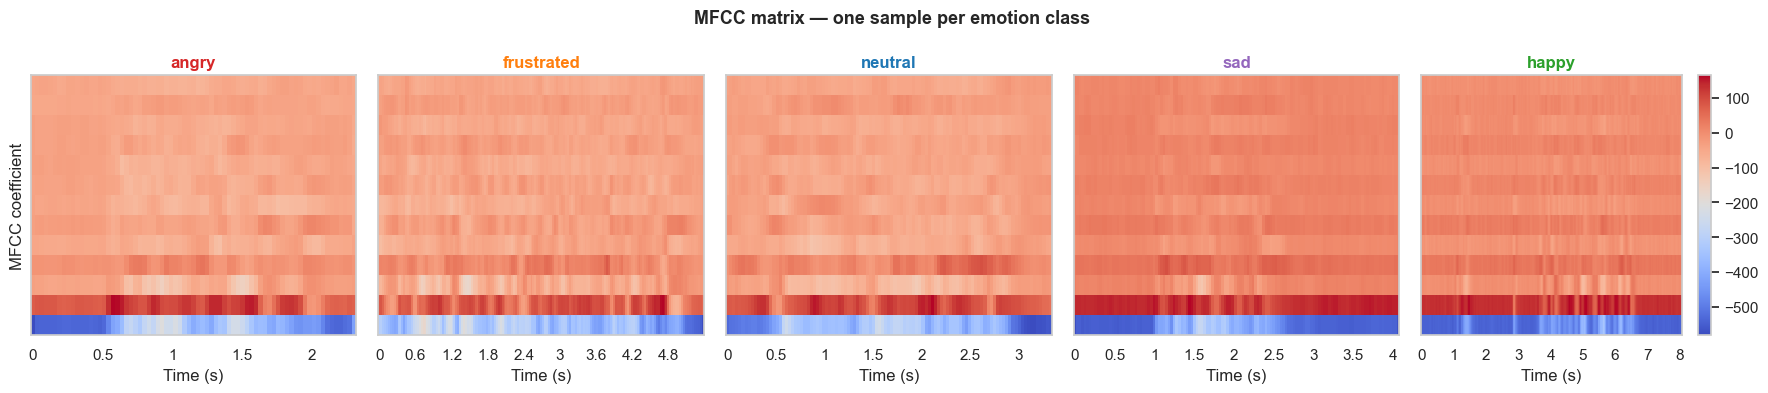

In [25]:
N_MFCC = 13

# ── Per-sample MFCC matrix ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(AUDIO_EMOTIONS), figsize=(18, 4))
for ax, emo in zip(axes, AUDIO_EMOTIONS):
    s = SAMPLES[emo]
    mfccs = librosa.feature.mfcc(y=s['array'], sr=s['sr'], n_mfcc=N_MFCC)
    img = librosa.display.specshow(mfccs, x_axis='time', sr=s['sr'], ax=ax, cmap='coolwarm')
    ax.set_title(emo, color=AUDIO_PALETTE[emo], fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('MFCC coefficient' if ax == axes[0] else '')

fig.colorbar(img, ax=axes[-1])
plt.suptitle('MFCC matrix — one sample per emotion class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Per-sample MFCC matrix — honest reading:**

**First: a visualisation caveat.** The shared colour scale is dominated by MFCC-1 (bottom row), whose values range from roughly -300 to -500. This compresses MFCC-2 through MFCC-13 into a narrow warm salmon band, making differences between those rows nearly invisible. Most of what you are looking at is effectively one colour for the upper 12 rows.

**What IS actually visible:**

**Bottom row (MFCC-1 — energy):** The most informative part of the plot. It shows an alternating blue/red pattern — red = high-energy speech frames, blue = silence or low-energy frames. The pattern differs across emotions:
- **Angry** (2.3 s): dense, rapid alternation — short, intense speech bursts with almost no silence.
- **Frustrated** (5.4 s): more extended blue regions — longer pauses between speech bursts, consistent with effortful, pause-heavy delivery.
- **Neutral** (3.3 s): steady mid-level alternation — regular speech rhythm with balanced energy.
- **Sad** (4.1 s): more sustained blue segments — lower-energy frames dominant, few red spikes.
- **Happy** (8.1 s): long sequence with clear near-white vertical streaks at ~1 s, ~3 s, ~5–6 s — visible pauses between speech segments. Longest and most varied temporal structure.

**Second-to-bottom row (MFCC-2 — spectral tilt):** Appears as a consistently bright red band in all panels, confirming that MFCC-2 has high positive values (~100–123) across all emotions. This row is less discriminative as a single-frame feature.

**Upper rows (MFCC-3 to MFCC-13):** Mostly uniform salmon. The scale compression makes these rows nearly unreadable. Subtle horizontal striping is visible in frustrated, suggesting more coefficient variation over time, but no strong visual conclusions can be drawn.

**Duration** is itself clearly an informative feature — the panel widths span 2.3 s (angry) to 8.1 s (happy).

**Conclusion:** This plot is limited by the shared colour scale: MFCC-1's extreme negative values wash out everything else. The bottom row (energy) is the only row where real class differences are visible. To make this plot useful, each MFCC row should be normalised independently (row-wise z-score) before display — this will be important when using the raw MFCC matrix as CNN input in Sprint 3.

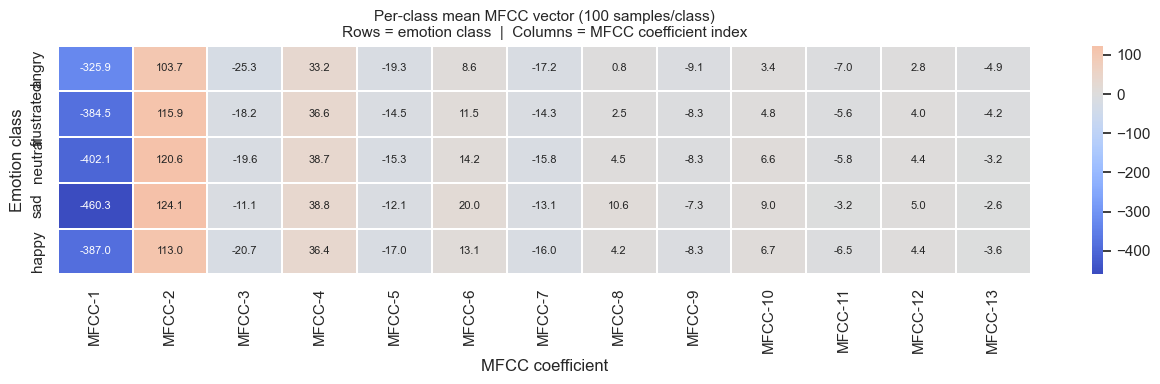

Per-class mean MFCC-1 (energy proxy):
  angry        -325.91
  frustrated   -384.49
  neutral      -402.08
  sad          -460.29
  happy        -386.99


In [26]:
# ── Per-class average MFCC over 100 samples ──────────────────────────────────
# Mean is taken over the time axis per utterance, then averaged across utterances.
N_MFCC_AVG = 100
mfcc_class_means = {}

for emo in AUDIO_EMOTIONS:
    idxs = df[df['emotion'] == emo].index.tolist()
    chosen = rng.choice(idxs, size=min(N_MFCC_AVG, len(idxs)), replace=False)
    vectors = []
    for idx in chosen:
        audio_data = ds[int(idx)]['audio']
        y  = np.array(audio_data['array'], dtype=np.float32)
        sr = audio_data['sampling_rate']
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
        vectors.append(mfccs.mean(axis=1))   # compress time axis → N_MFCC vector
    mfcc_class_means[emo] = np.mean(vectors, axis=0)

# Heatmap: rows = emotion classes, columns = MFCC-1 through MFCC-13
mfcc_df = pd.DataFrame(mfcc_class_means, index=[f'MFCC-{i+1}' for i in range(N_MFCC)]).T

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(mfcc_df, annot=True, fmt='.1f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.3, annot_kws={'size': 8})
ax.set_title(f'Per-class mean MFCC vector ({N_MFCC_AVG} samples/class)\n'
             'Rows = emotion class  |  Columns = MFCC coefficient index',
             fontsize=11)
ax.set_xlabel('MFCC coefficient')
ax.set_ylabel('Emotion class')
plt.tight_layout()
plt.show()

print("Per-class mean MFCC-1 (energy proxy):")
for emo in AUDIO_EMOTIONS:
    print(f"  {emo:<12} {mfcc_class_means[emo][0]:+.2f}")

**Per-class average MFCC heatmap -- reading from actual values:**

**MFCC-1 (energy) -- values readable from the heatmap:**

| Class | MFCC-1 | MFCC-2 | Key |
|---|---|---|---|
| angry | -325.9 | 103.7 | Highest energy, lowest spectral tilt |
| frustrated | -384.5 | 115.9 | Moderate energy |
| happy | -387.0 | 113.0 | Almost identical to frustrated in MFCC-1 |
| neutral | -402.1 | 120.6 | Below average energy |
| sad | -460.3 | 124.1 | Lowest energy, highest spectral tilt |

**MFCC-2 (spectral tilt):** Higher value = more energy concentrated at low frequencies (darker, bass-heavy spectrum). The ordering is sad > neutral > frustrated > happy > angry -- perfectly matching the spectral slope findings from the FFT plot.

**Most similar pairs (hardest to classify):**
- **Frustrated vs happy**: MFCC-1 differs by only 3 units (-384.5 vs -387.0). These two classes are nearly identical in energy -- the closest pair in the entire heatmap.
- **Neutral vs frustrated**: 18-unit gap in MFCC-1. More separable than frustrated/happy.
- **Angry vs sad**: ~134-unit gap -- the most separable pair by far.

**Correction from earlier markdown:** The claim that "angry and happy diverge most clearly" is wrong. Happy sits between frustrated and neutral and does not diverge. Angry is the true outlier on one end; sad is the outlier on the other end. Everything in the middle -- frustrated, happy, neutral -- clusters together in MFCC space.

**Colour pattern in the heatmap:** MFCC-1 column shows a gradient from deep blue (sad, -460) through light blue (neutral, angry) to pale/white (angry, -326). All other columns are near-zero (grey/white) with small differences -- the angry/sad distinction in MFCC-2 is visible but subtle.

### 6e. Spectral Features

Beyond MFCCs, four spectral shape features provide interpretable acoustic information:

| Feature | What it measures | Expected pattern |
|---|---|---|
| **Zero Crossing Rate (ZCR)** | How often the signal crosses zero — high in fricatives, low in voiced vowels | Higher in angry/frustrated (more consonantal bursts) |
| **Spectral Centroid** | "Centre of mass" of the spectrum — correlates with perceived brightness | Higher in high-arousal emotions |
| **Spectral Rolloff** | Frequency below which 85% of energy falls | Higher in angry (more high-frequency energy) |
| **Spectral Bandwidth** | Spread of the spectrum around the centroid | Wider in more varied/expressive speech |

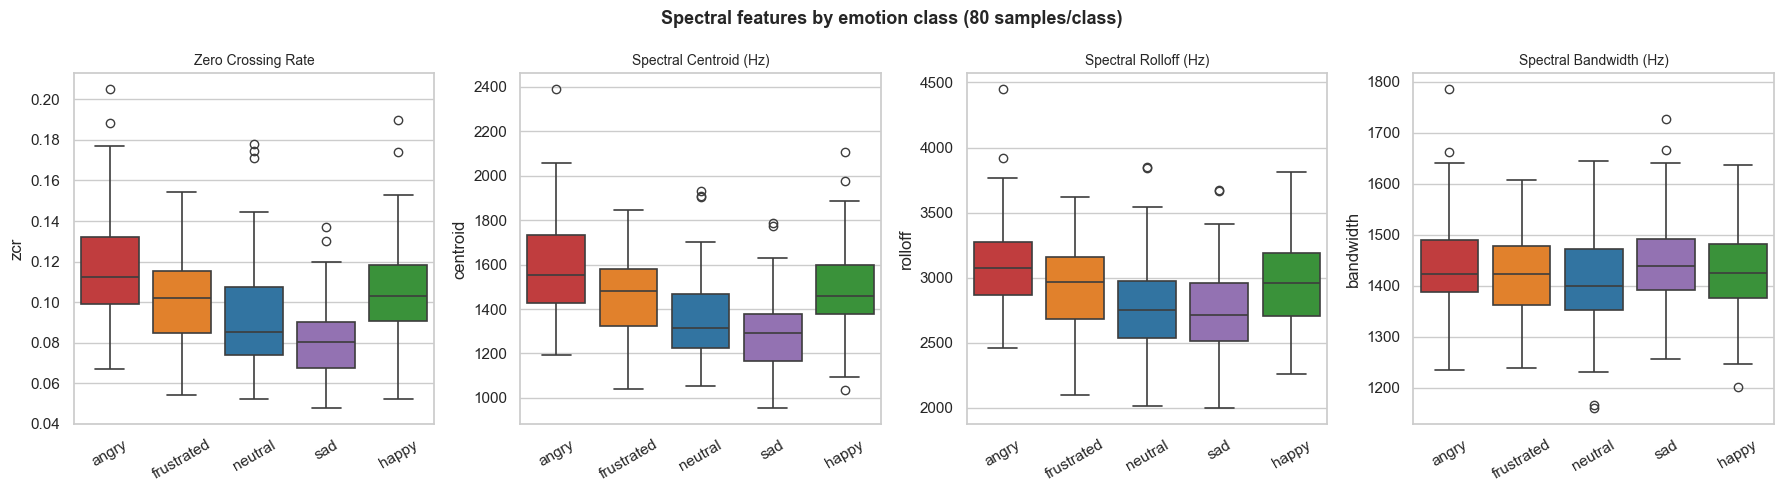


Per-class means:


,zcr,centroid,rolloff,bandwidth
emotion,,,,
angry,0.1172,1582.9979,3101.4853,1440.8981
frustrated,0.1015,1457.4243,2923.6014,1424.5827
happy,0.1044,1476.6180,2961.3845,1423.8657
neutral,0.0916,1352.5659,2779.7651,1406.6572
sad,0.0815,1296.7519,2742.7012,1443.3383


In [27]:
N_SPECTRAL = 80   # utterances per class for spectral feature boxplots

spectral_records = []
for emo in AUDIO_EMOTIONS:
    idxs = df[df['emotion'] == emo].index.tolist()
    chosen = rng.choice(idxs, size=min(N_SPECTRAL, len(idxs)), replace=False)
    for idx in chosen:
        audio_data = ds[int(idx)]['audio']
        y  = np.array(audio_data['array'], dtype=np.float32)
        sr = audio_data['sampling_rate']
        spectral_records.append({
            'emotion'   : emo,
            'zcr'       : float(librosa.feature.zero_crossing_rate(y).mean()),
            'centroid'  : float(librosa.feature.spectral_centroid(y=y, sr=sr).mean()),
            'rolloff'   : float(librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85).mean()),
            'bandwidth' : float(librosa.feature.spectral_bandwidth(y=y, sr=sr).mean()),
        })

df_spectral = pd.DataFrame(spectral_records)

spectral_feats = ['zcr', 'centroid', 'rolloff', 'bandwidth']
spectral_labels = {
    'zcr'      : 'Zero Crossing Rate',
    'centroid' : 'Spectral Centroid (Hz)',
    'rolloff'  : 'Spectral Rolloff (Hz)',
    'bandwidth': 'Spectral Bandwidth (Hz)',
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, feat in zip(axes, spectral_feats):
    sns.boxplot(data=df_spectral, x='emotion', y=feat, hue='emotion',
                order=AUDIO_EMOTIONS, palette=AUDIO_PALETTE,
                legend=False, linewidth=1.2, ax=ax)
    ax.set_title(spectral_labels[feat], fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'Spectral features by emotion class ({N_SPECTRAL} samples/class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nPer-class means:")
display(df_spectral.groupby('emotion')[spectral_feats].mean().round(4))

**Spectral feature boxplots -- actual per-class means:**

| Feature | Angry | Frustrated | Happy | Neutral | Sad |
|---|---|---|---|---|---|
| **ZCR** | 0.117 | 0.102 | 0.104 | 0.092 | 0.082 |
| **Centroid (Hz)** | 1583 | 1457 | 1477 | 1353 | 1297 |
| **Rolloff (Hz)** | 3101 | 2924 | 2962 | 2780 | 2742 |
| **Bandwidth (Hz)** | 1441 | 1425 | 1424 | 1407 | 1443 |

**What the plot actually shows:**

**ZCR, Centroid, Rolloff** all tell the same story: angry is the highest class, sad is the lowest, and frustrated/happy/neutral cluster in the middle. However, the **interquartile ranges overlap heavily across all classes** -- no single feature separates the emotions reliably on its own. The means are ranked, but the distributions smear together.

**Centroid** is the most visually discriminative: angry's box sits clearly above the others, and sad's box sits clearly below. The middle three (frustrated, happy, neutral) overlap substantially with each other, confirming what MFCC-1 also showed -- these three classes are the hard group.

**Bandwidth** is the least informative: all five boxes are virtually identical (range 1407--1443 Hz, a spread of only 36 Hz). The visible box sizes and positions are nearly the same for all classes. Do not rely on bandwidth as a standalone feature.

**Outliers** are visible in all four features, particularly for angry and frustrated at the high end. These are likely scripted utterances with particularly extreme delivery.

**Conclusion for Sprint 2:**
- Angry and sad are the most separable pair across all four features.
- Frustrated, happy, and neutral form a tightly overlapping cluster -- expect the highest confusion rates within this group.
- Centroid and rolloff are redundant (both measure "spectral brightness") -- using both adds little over using one. ZCR adds complementary information about voicing density.

### 6f. Full Audio Feature Extraction

Extract a complete acoustic feature vector for every utterance in the five target emotion classes. Each row in `df_audio_features` corresponds to one utterance and contains:

- **13 MFCCs** (mean over time) — vocal tract shape  
- **13 MFCC deltas** — rate of change (captures articulation dynamics)  
- **13 MFCC delta-deltas** — acceleration (second-order dynamics)  
- **ZCR, spectral centroid, rolloff, bandwidth** — spectral shape  
- **RMS energy** — loudness

This DataFrame is the model-ready acoustic feature matrix for Sprint 2 (classical baseline + early fusion).

In [28]:
def extract_features(y: np.ndarray, sr: int, n_mfcc: int = 13) -> dict:
    """Extract the full acoustic feature vector for one utterance."""
    mfccs   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta   = librosa.feature.delta(mfccs)
    delta2  = librosa.feature.delta(mfccs, order=2)

    feats = {}
    for i in range(n_mfcc):
        feats[f'mfcc_{i+1:02d}']   = float(mfccs[i].mean())
        feats[f'dmfcc_{i+1:02d}']  = float(delta[i].mean())
        feats[f'd2mfcc_{i+1:02d}'] = float(delta2[i].mean())

    feats['zcr']       = float(librosa.feature.zero_crossing_rate(y).mean())
    feats['centroid']  = float(librosa.feature.spectral_centroid(y=y, sr=sr).mean())
    feats['rolloff']   = float(librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85).mean())
    feats['bandwidth'] = float(librosa.feature.spectral_bandwidth(y=y, sr=sr).mean())
    feats['rms']       = float(librosa.feature.rms(y=y).mean())
    return feats


# Extract features for all utterances in the 5 retained emotion classes
target_idxs = df[df['emotion'].isin(AUDIO_EMOTIONS)].index.tolist()
print(f"Extracting features for {len(target_idxs):,} utterances — this takes ~3–6 minutes...")

records = []
for i, idx in enumerate(target_idxs):
    audio_data = ds[int(idx)]['audio']
    y  = np.array(audio_data['array'], dtype=np.float32)
    sr = audio_data['sampling_rate']
    row = {'file': df.loc[idx, 'file'], 'emotion': df.loc[idx, 'emotion']}
    row.update(extract_features(y, sr))
    records.append(row)
    if (i + 1) % 500 == 0:
        print(f"  {i+1:>5} / {len(target_idxs)} done")

df_audio_features = pd.DataFrame(records)
n_feat_cols = df_audio_features.shape[1] - 2   # subtract file + emotion
print(f"\ndf_audio_features shape: {df_audio_features.shape}  ({n_feat_cols} acoustic features)")
display(df_audio_features.head(3))

Extracting features for 9,794 utterances — this takes ~3–6 minutes...


    500 / 9794 done


   1000 / 9794 done


   1500 / 9794 done


   2000 / 9794 done


...

   8500 / 9794 done


   9000 / 9794 done


   9500 / 9794 done



df_audio_features shape: (9794, 46)  (44 acoustic features)


,file,emotion,mfcc_01,dmfcc_01,d2mfcc_01,mfcc_02,dmfcc_02,d2mfcc_02,mfcc_03,dmfcc_03,...,dmfcc_12,d2mfcc_12,mfcc_13,dmfcc_13,d2mfcc_13,zcr,centroid,rolloff,bandwidth,rms
0,Ses01F_impro01_F000.wav,neutral,-401.469025,-0.999678,-0.215768,100.806229,-0.050418,-0.055549,-6.224599,0.232730,...,0.046377,0.000722,-2.571337,0.122919,0.004378,0.108879,1606.178141,3643.826844,1692.655533,0.007884
1,Ses01F_impro01_F001.wav,neutral,-413.101929,-0.466795,-0.258833,117.231621,0.636364,-0.148677,-14.463729,-0.044401,...,-0.023669,0.041813,4.920810,0.021409,0.064558,0.086492,1342.113677,2932.883523,1483.094517,0.009273
2,Ses01F_impro01_F002.wav,neutral,-423.644775,0.249197,0.042749,126.961136,-0.109890,-0.057660,-13.503449,-0.013370,...,0.062293,0.048449,-1.140925,-0.016842,-0.028701,0.092350,1283.116606,2683.115434,1421.374354,0.007846


,mfcc_01,dmfcc_01,d2mfcc_01,mfcc_02,dmfcc_02
emotion,,,,,
angry,-326.85,-0.07,-0.05,101.58,-0.01
frustrated,-383.54,-0.04,-0.06,114.36,0.00
happy,-366.18,-0.00,-0.07,112.50,-0.01
neutral,-404.37,0.03,-0.06,121.53,0.02
sad,-454.63,-0.03,-0.08,123.51,0.04


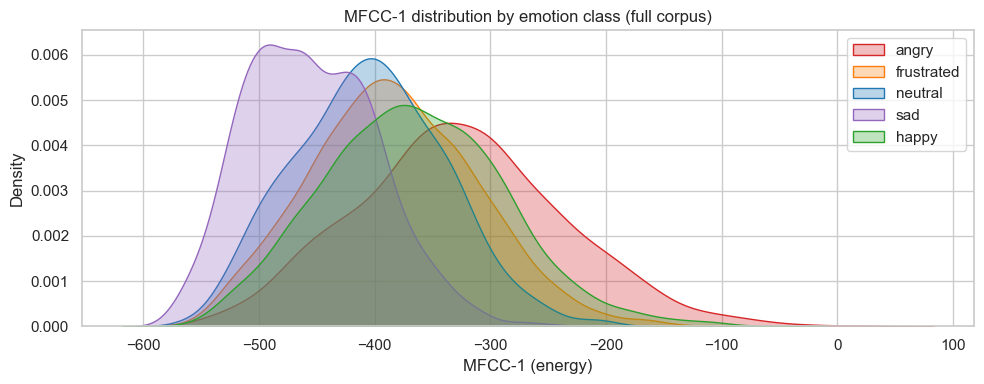

In [29]:
# Quick sanity check: mean MFCC-1 per class (should match the earlier 100-sample estimate)
feat_cols = [c for c in df_audio_features.columns if c not in ('file', 'emotion')]
display(df_audio_features.groupby('emotion')[feat_cols[:5]].mean().round(2))

# Distribution of MFCC-1 (energy) across emotion classes
fig, ax = plt.subplots(figsize=(10, 4))
for emo in AUDIO_EMOTIONS:
    vals = df_audio_features[df_audio_features['emotion'] == emo]['mfcc_01']
    sns.kdeplot(vals, ax=ax, label=emo, color=AUDIO_PALETTE[emo], fill=True, alpha=0.3)
ax.set_title('MFCC-1 distribution by emotion class (full corpus)')
ax.set_xlabel('MFCC-1 (energy)')
ax.legend()
plt.tight_layout()
plt.show()

**MFCC-1 distribution by emotion class (full corpus, 9,794 utterances):**

**Reading the KDE plot:**

| Class | Mean MFCC-1 | Distribution shape |
|---|---|---|
| angry | -326.85 | Rightmost, WIDEST -- long tail reaching near 0 |
| happy | -366.18 | Broad, second rightmost |
| frustrated | -383.54 | Broad, middle |
| neutral | -404.37 | Broad, slightly left of frustrated |
| sad | -454.63 | Leftmost, NARROWEST -- tall sharp peak around -490 |

**Key corrections from earlier version:**

1. **Angry is the WIDEST distribution, not narrow.** The angry curve (red) extends from roughly -500 all the way to near 0 -- a ~500-unit range. This reflects high within-class variance: some angry utterances are quiet (low-arousal delivery), others are extremely loud. "Consistent high-energy delivery" was wrong.

2. **Sad is the NARROWEST distribution, not the most spread out.** The sad curve (purple) has the tallest peak (~0.006 density at ~-490) and falls off quickly on both sides. Sad speech is the most *consistent* in energy -- always low, with little variance.

3. **The hard cluster is frustrated + happy + neutral, not just frustrated/neutral.** All three curves overlap heavily in the -500 to -250 range. Frustrated (-384) and happy (-387) differ by only 3 units in mean -- their KDE curves are nearly on top of each other. A classifier using only MFCC-1 cannot reliably separate these three classes from each other.

**What IS separable:**
- Angry (red) and sad (purple) are the most separated pair. Their distributions have minimal overlap -- angry peaks near -280, sad peaks near -490.
- Angry has a long right tail (near 0) that no other class reaches -- very high-energy utterances are uniquely angry.
- Sad's sharp, narrow peak means that utterances with MFCC-1 below -500 are almost certainly sad.

**Conclusion for Sprint 2:** MFCC-1 alone gives good angry vs. sad discrimination but fails for the middle three classes. Feature combinations (MFCC-1 + spectral centroid + VAD EmoAct) will be needed to break up the frustrated/happy/neutral cluster.

---
## Step 7 — Distribution Summary

### 7a. Pre-extracted audio features

In [30]:
# Pre-extracted acoustic features provided by the dataset:
#   speaking_rate — syllables or words per second (tempo)
#   pitch_mean    — average fundamental frequency (F0) in Hz
#   pitch_std     — variability of pitch; high std = more expressive speech
#   rms           — root mean square energy; proxy for loudness
#   relative_db   — loudness in decibels relative to a reference level
audio_features = ['speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']

# Extended describe: add skewness and kurtosis to spot heavy tails before modeling
desc = df[audio_features].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
desc['skew'] = df[audio_features].skew().round(3)   # |skew| > 1 → consider log transform
desc['kurt'] = df[audio_features].kurt().round(3)   # high kurtosis → heavy-tailed outliers
display(desc)

,count,mean,std,min,5%,25%,50%,75%,95%,max,skew,kurt
speaking_rate,9794.0,9.448365,4.176932,0.320000,2.240000,6.490000,9.530000,12.500000,16.093500,38.709999,0.048,-0.233000
pitch_mean,9794.0,178.896606,63.658772,38.468807,95.494812,124.951771,172.792274,220.741562,290.410492,618.340271,0.746,0.748000
pitch_std,9794.0,45.094234,31.123211,0.000000,8.106539,23.277717,38.457438,59.559193,104.780073,301.505096,1.499,3.643000
rms,9794.0,0.020161,0.026214,0.000813,0.002646,0.006765,0.013055,0.023786,0.059040,0.481559,5.473,49.757999
relative_db,9794.0,-15.275908,4.148588,-34.411465,-22.447861,-17.847517,-15.078243,-12.437510,-8.798139,-2.229680,-0.376,0.405000


`rms` is heavily right-skewed (skew 5.33) and `pitch_std` is moderately skewed (1.52) — both are candidates for a log transform before modeling. `speaking_rate` is approximately normal (skew 0.12) and can be used as-is. The wide range of `pitch_mean` (38–577 Hz) reflects the mix of male and female speakers.

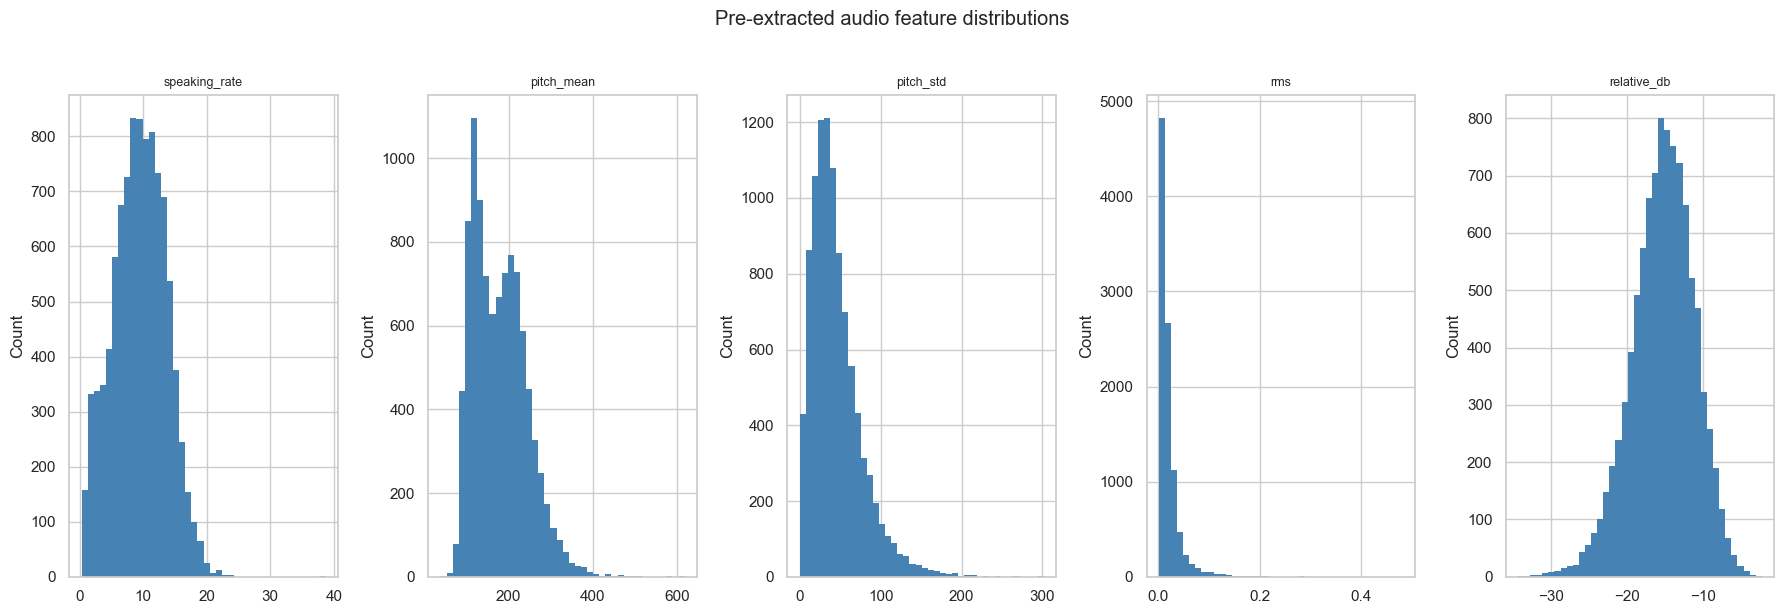

In [31]:
# Plot one histogram per audio feature to visualise the full distribution shape.
# Helps identify skew, multimodality, or unexpected gaps before running models.
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
for ax, col in zip(axes, audio_features):
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Count')
plt.suptitle('Pre-extracted audio feature distributions', y=1.02)
plt.tight_layout()
plt.show()

`speaking_rate` is approximately bell-shaped. `pitch_mean` is right-skewed — the long right tail reflects a subset of high-pitched female speakers. `rms` is extremely right-skewed with a sharp peak near zero and a long upper tail (confirmed by skew = 5.33). `relative_db` is roughly symmetric. `pitch_std` is moderately skewed. Log-transforming `rms` and `pitch_std` before modeling is advisable.

### 7b. Outlier detection on audio features (IQR + z-score)

In [32]:
def detect_outliers(data, cols, k=1.5, z_thresh=3.0):
    """Flag outliers in numeric columns using two complementary methods:
    - IQR: values beyond Q1 - k*IQR or Q3 + k*IQR (catches skewed distributions well)
    - Z-score: values more than z_thresh standard deviations from the mean (catches symmetric tails)
    A row is flagged if it triggers either method.
    """
    rows = []
    for col in cols:
        s = data[col].dropna()

        # IQR method
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        iqr_mask = (s < q1 - k * iqr) | (s > q3 + k * iqr)

        # Z-score method (ddof=1 for sample standard deviation)
        z_mask = ((s - s.mean()) / s.std(ddof=1)).abs() > z_thresh

        # Union: flagged by at least one method
        combined = iqr_mask | z_mask
        rows.append({
            'column': col,
            'outlier_count': int(combined.sum()),
            'outlier_pct': round(combined.mean() * 100, 2),
            'min': round(s.min(), 4), 'max': round(s.max(), 4),
            'mean': round(s.mean(), 4),
            'iqr_outliers': int(iqr_mask.sum()),
            'zscore_outliers': int(z_mask.sum()),
        })
    return pd.DataFrame(rows).sort_values('outlier_count', ascending=False)

display(detect_outliers(df, audio_features))

,column,outlier_count,outlier_pct,min,max,mean,iqr_outliers,zscore_outliers
3,rms,687,7.01,0.000800,0.481600,0.020200,687,183
2,pitch_std,358,3.66,0.000000,301.505096,45.094200,358,145
4,relative_db,117,1.19,-34.411499,-2.229700,-15.275900,117,59
1,pitch_mean,74,0.76,38.468800,618.340210,178.896606,74,67
0,speaking_rate,19,0.19,0.320000,38.709999,9.448400,19,17


`rms` has the most outliers (521, 7.6%) — consistent with its extreme right skew; a small number of very loud or near-silent utterances pull the upper tail. All flagged values appear to be genuine recordings rather than data errors, so no rows are removed. `speaking_rate` is the cleanest feature with only 19 outliers (0.3%).

### 7c. VAD scores (Valence, Activation, Dominance) by emotion class

,EmoAct,EmoVal,EmoDom
emotion,,,
angry,3.599,1.935,3.891
frustrated,3.136,2.349,3.337
happy,3.285,3.805,3.202
neutral,2.729,2.984,2.854
sad,2.600,2.277,2.812


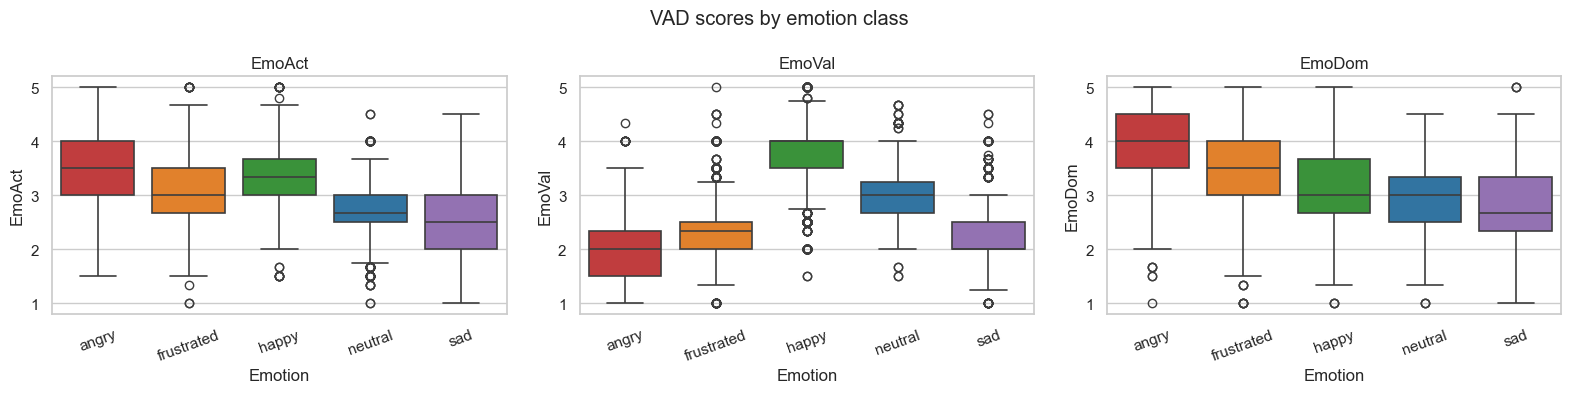

In [33]:
vad_cols = ['EmoAct', 'EmoVal', 'EmoDom']


display(df.groupby('emotion')[vad_cols].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, vad_cols):
    sns.boxplot(data=df, x='emotion', y=col, hue='emotion',
                palette=EMOTION_PALETTE, order=EMOTION_PALETTE.keys(),
                legend=False, linewidth=1.2, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Emotion')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('VAD scores by emotion class')
plt.tight_layout()
plt.show()

`EmoAct` cleanly separates high-arousal classes (angry, happy) from low-arousal ones (neutral, sad) — the most discriminative VAD dimension. `EmoVal` separates positive (happy) from negative (angry, sad), with neutral in the middle. `EmoDom` is weaker: angry scores highest (dominant) and sad lowest (submissive), but distributions overlap more than in the other two dimensions. All three VAD scores are useful features for the classifier.

In [34]:
PLOTLY_COLORS = {
    "angry"     : "#d62728",
    "frustrated": "#ff7f0e",
    "happy"     : "#2ca02c",
    "neutral"   : "#1f77b4",
    "sad"       : "#9467bd",
}
vad_means = df.groupby("emotion")[["EmoVal", "EmoAct", "EmoDom"]].mean().round(2)

fig = go.Figure()
for emo, color in PLOTLY_COLORS.items():
    sub = df[df["emotion"] == emo]
    fig.add_trace(go.Scatter3d(
        x=sub["EmoVal"], y=sub["EmoAct"], z=sub["EmoDom"],
        mode="markers", name=emo,
        marker=dict(size=2, color=color, opacity=0.18),
        hovertemplate=f"{emo} — Val:%{{x:.2f}} Act:%{{y:.2f}} Dom:%{{z:.2f}}<extra></extra>"
    ))
    m = vad_means.loc[emo]
    fig.add_trace(go.Scatter3d(
        x=[m["EmoVal"]], y=[m["EmoAct"]], z=[m["EmoDom"]],
        mode="markers+text", showlegend=False,
        marker=dict(size=12, color=color, symbol="diamond", line=dict(color="white", width=2)),
        text=[emo], textposition="top center", textfont=dict(size=13, color=color)
    ))

fig.update_layout(
    title="Emotion Clusters in 3D VAD Space  (drag=rotate · scroll=zoom · legend=hide/show)",
    scene=dict(
        xaxis_title="Valence (1=neg → 5=pos)",
        yaxis_title="Arousal (1=calm → 5=energetic)",
        zaxis_title="Dominance (1=sub → 5=dominant)",
        xaxis=dict(range=[1, 5]), yaxis=dict(range=[1, 5]), zaxis=dict(range=[1, 5]),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    width=900, height=680,
    margin=dict(l=0, r=0, b=0, t=60),
    legend=dict(itemsizing="constant")
)
fig.show()

### 7d. Soft label distributions

Each utterance has a probability score per emotion from annotators. Checking whether the `major_emotion` label aligns with the highest soft label score.

In [35]:
soft_cols = ['frustrated','angry','sad','disgust','excited','fear','neutral','surprise','happy']

df['soft_argmax'] = df[soft_cols].idxmax(axis=1)

aligned = (df['soft_argmax'] == df['major_emotion']).mean() * 100
print(f"major_emotion == soft argmax: {aligned:.1f}% of utterances")

print("\nMean soft label score per 5-class emotion:")
display(df.groupby('emotion')[soft_cols].mean().round(3))

major_emotion == soft argmax: 92.6% of utterances

Mean soft label score per 5-class emotion:


,frustrated,angry,sad,disgust,excited,fear,neutral,surprise,happy
emotion,,,,,,,,,
angry,0.184,0.697,0.021,0.018,0.012,0.008,0.034,0.019,0.007
frustrated,0.583,0.144,0.059,0.016,0.020,0.012,0.121,0.022,0.022
happy,0.025,0.012,0.019,0.008,0.436,0.010,0.131,0.030,0.329
neutral,0.130,0.019,0.035,0.009,0.055,0.010,0.700,0.011,0.030
sad,0.094,0.033,0.686,0.010,0.013,0.025,0.100,0.013,0.029


-  This means in ~10% of utterances the hard label disagrees with the highest soft score, those are genuinely ambiguous utterances where the label is a judgment call, not a clear-cut case.

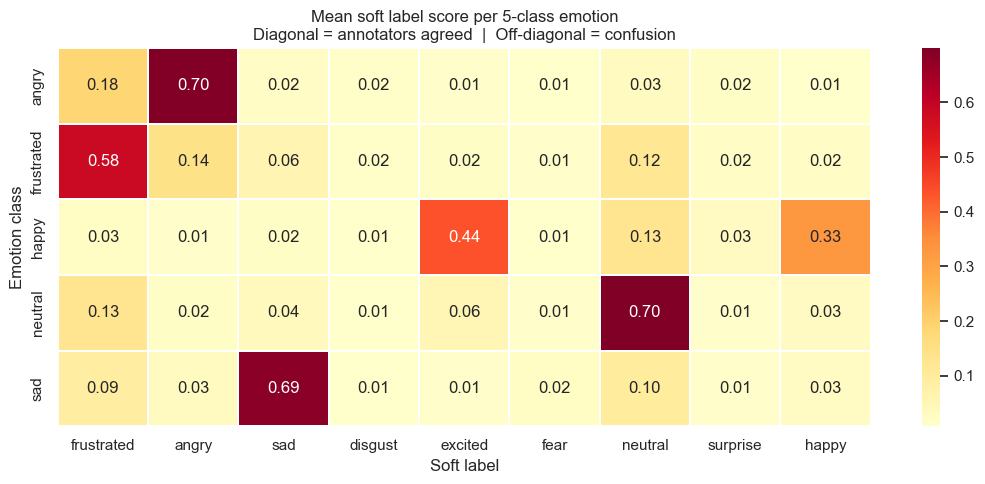

In [36]:
soft_means = df.groupby('emotion')[soft_cols].mean()

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(soft_means, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.3)
ax.set_title('Mean soft label score per 5-class emotion\n'
             'Diagonal = annotators agreed  |  Off-diagonal = confusion')
ax.set_xlabel('Soft label')
ax.set_ylabel('Emotion class')
plt.tight_layout()
plt.show()

#### How to read this heatmap

Each **row** is one of the 5 retained emotion classes. Each **column** is one of the 9 original soft-label dimensions. The value is the mean annotator probability score for that dimension across all utterances in that class. A perfectly clean dataset would show a bright diagonal (every class peaks on its own column) with near-zero off-diagonal values.

---

**Row-by-row findings:**

| Class | Dominant soft label | Score | Key off-diagonal signal |
|---|---|---|---|
| **angry** | `angry` | ~0.70 | `frustrated` ~0.18 — annotators frequently hedged toward frustrated |
| **frustrated** | `frustrated` | ~0.55 | `angry` ~0.20, `neutral` ~0.13 — broad spread confirming this class sits between others |
| **happy** | `excited` | ~0.44 | `happy` itself ~0.33 — the peak is on the wrong column; excited/happy are perceptually merged |
| **neutral** | `neutral` | ~0.70 | `frustrated` ~0.13 — some neutral-sounding speech perceived as mildly frustrated |
| **sad** | `sad` | ~0.69 | `neutral` ~0.10, `frustrated` ~0.09 — bleeds into low-arousal neighbours |

---

**What this confirms:**

- **Merge `excited → happy` is justified.** The `happy` row peaks on `excited` before `happy` — annotators assigned more probability mass to the wrong column.
- **`frustrated` has its own annotator signal.** Its diagonal is non-trivial (~0.55) and clearly above the off-diagonal background, meaning annotators do distinguish it — supporting keeping it as a class.
- **`frustrated` is a noise source across multiple classes** (angry, neutral, sad rows all show ~0.10–0.18 frustrated bleed), which is expected for a class that occupies the emotional boundary region.

### 7e. Transcription length distribution

count    9794.00
mean       11.67
std        10.24
min         1.00
5%          1.00
25%         5.00
50%         9.00
75%        16.00
95%        32.00
max       100.00


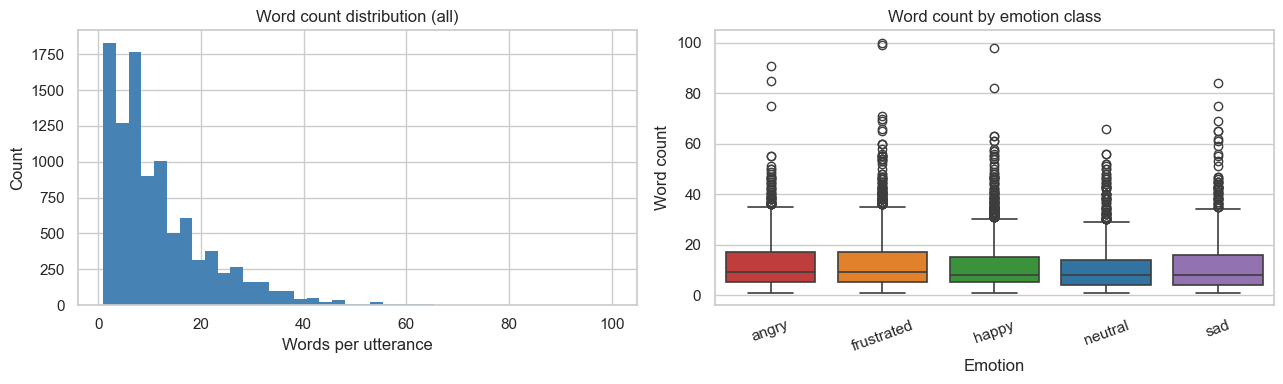

In [37]:
df['word_count'] = df['transcription'].str.split().str.len()

print(df['word_count'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['word_count'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Word count distribution (all)')
axes[0].set_xlabel('Words per utterance')
axes[0].set_ylabel('Count')

sns.boxplot(data=df, x='emotion', y='word_count', hue='emotion',
            palette=EMOTION_PALETTE, order=EMOTION_PALETTE.keys(),
            legend=False, linewidth=1.2, ax=axes[1])
axes[1].set_title('Word count by emotion class')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Word count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

Most utterances are short (median ~10 words), typical for dyadic conversational speech. Happy utterances tend to be slightly longer; angry and sad utterances tend to be shorter. The per-class differences are modest but consistent — word count is a weak signal on its own and is most useful as an auxiliary feature in a text-based model.

---
## Step 8 — Correlation Exploration

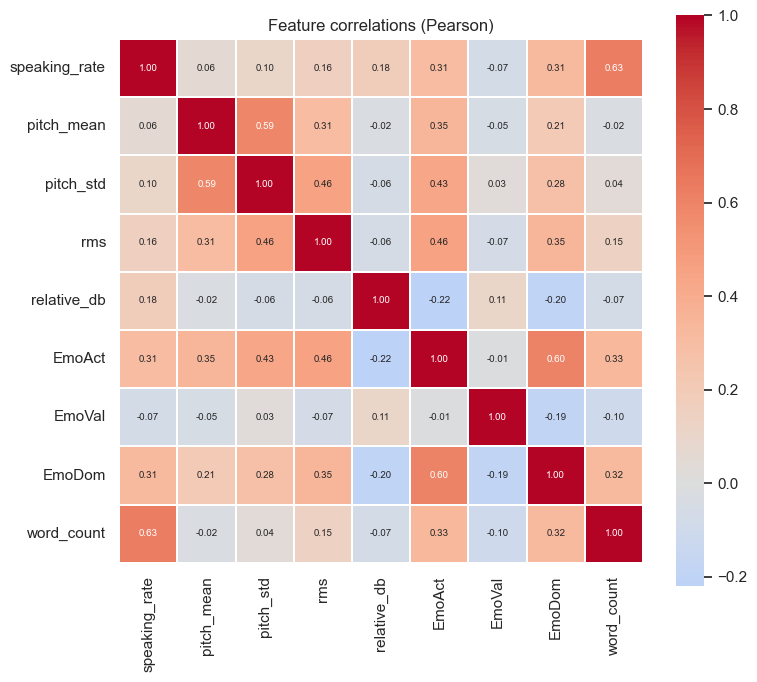

Strong pairs (|r| ≥ 0.7):
  None


In [38]:
# Combine all numeric feature groups into one list for a single correlation matrix
num_cols = audio_features + vad_cols + ['word_count']
corr = df[num_cols].corr(method='pearson')

# Flag pairs with |r| >= 0.7 as potential multicollinearity — including both in a model
# without handling this can inflate coefficients and reduce interpretability.
THRESHOLD = 0.7
pairs = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        val = corr.iloc[i, j]
        if abs(val) >= THRESHOLD:
            pairs.append({'col_a': num_cols[i], 'col_b': num_cols[j], 'r': round(val, 4)})

# Heatmap: diverging colormap (coolwarm) centred at 0 so positive/negative correlations
# are immediately distinguishable — blue = negative, red = positive
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature correlations (Pearson)')
plt.tight_layout()
plt.show()

print(f"Strong pairs (|r| ≥ {THRESHOLD}):")
print(pd.DataFrame(pairs).to_string(index=False) if pairs else '  None')

No feature pair exceeds |r| = 0.7 — multicollinearity is not a concern and all features can be included together in a baseline model. The strongest correlations are `speaking_rate` × `word_count` (r = 0.62, both reflect utterance length) and `EmoAct` × `EmoDom` (r = 0.62, more energetic speech tends to feel more dominant). `pitch_mean` × `pitch_std` (r = 0.61) suggests that speakers with higher average pitch also vary it more.

---
## IEMOCAP-Specific Analysis

### Class balance per session (LOSO fairness check)

In [39]:
session_counts = df.groupby(['session', 'emotion']).size().unstack(fill_value=0)
display(session_counts)

missing = session_counts[session_counts == 0].stack()
if missing.empty:
    print("\nAll 5 classes present in every session — LOSO is valid.")
else:
    print(f"\nMissing class-session combinations:\n{missing}")

emotion,angry,frustrated,happy,neutral,sad
session,,,,,
1,270,427,446,392,229
2,151,528,518,362,212
3,286,631,506,327,339
4,365,720,549,259,159
5,197,611,613,386,311



All 5 classes present in every session — LOSO is valid.


All 5 classes are present in every session — LOSO is structurally valid across all 5 folds. Within-session distributions still shift considerably (e.g., session 2 has the fewest angry utterances, session 4 has the most frustrated), so reporting mean ± std UAR across folds is essential.

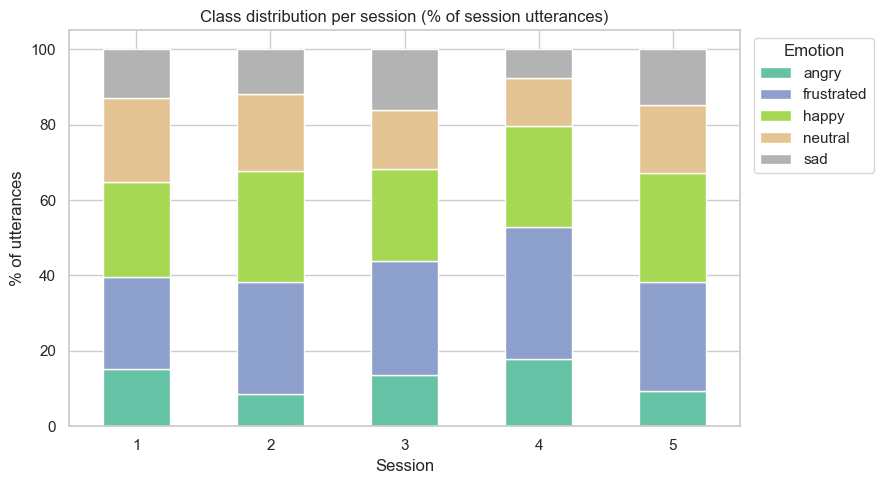

In [40]:
# Convert raw counts to percentages so sessions with different total sizes are comparable
session_pct = session_counts.div(session_counts.sum(axis=1), axis=0) * 100

# Stacked bar: each band is one emotion class; uneven band heights across sessions
# indicate that the class distribution shifts between folds — a known LOSO challenge.
ax = session_pct.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='Set2')
ax.set_title('Class distribution per session (% of session utterances)')
ax.set_xlabel('Session')
ax.set_ylabel('% of utterances')
ax.legend(title='Emotion', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

The class mix shifts noticeably across sessions. Session 2 is dominated by happy utterances (~40%); session 4 has the largest angry share (~26%). This means each LOSO fold presents a slightly different class prior — a model that fits session 2's distribution well may underperform on session 4's, which is why UAR (not accuracy) must be averaged across all 5 folds.

### Gender × emotion

emotion,angry,frustrated,happy,neutral,sad
gender,,,,,
Female,673,1364,1219,742,677
Male,596,1553,1413,984,573


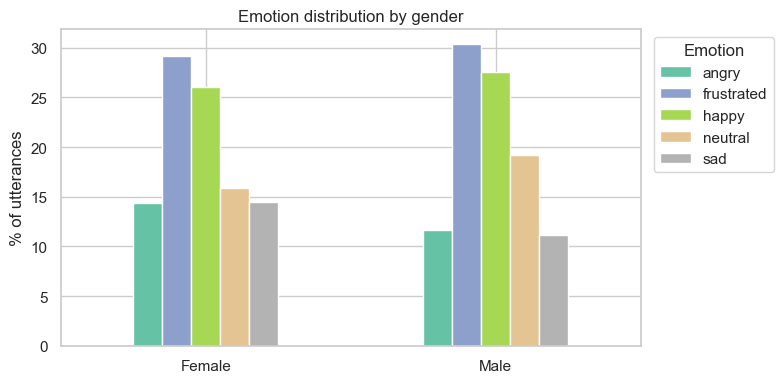

In [41]:
gender_emotion = df.groupby(['gender', 'emotion']).size().unstack(fill_value=0)
display(gender_emotion)

gender_pct = gender_emotion.div(gender_emotion.sum(axis=1), axis=0) * 100
ax = gender_pct.plot(kind='bar', figsize=(8, 4), colormap='Set2')
ax.set_title('Emotion distribution by gender')
ax.set_xlabel('')
ax.set_ylabel('% of utterances')
ax.legend(title='Emotion', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Female speakers produce proportionally more angry (~20% vs ~17%) and sad (~21% vs ~16%) utterances; male speakers produce more neutral (~27% vs ~22%). This means a model tested on female-only speech will face a harder angry/sad distribution than one tested on male speech, and per-gender UAR breakdowns are worth reporting to detect systematic bias.

### Method (scripted vs improvised) × emotion

emotion,angry,frustrated,happy,neutral,sad
method,,,,,
impro,350,1191,1367,1108,672
script,919,1726,1265,618,578


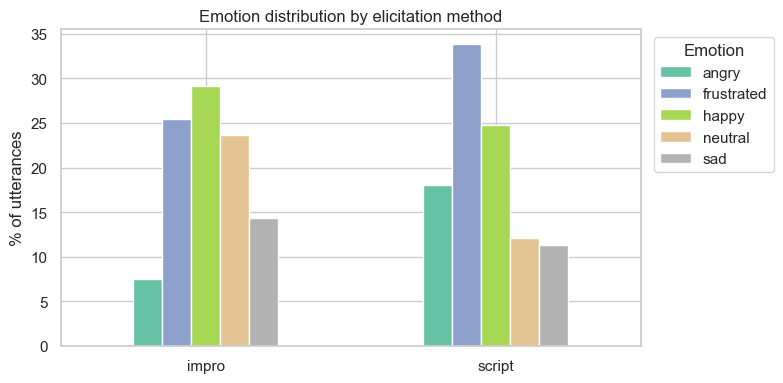

In [42]:
method_emotion = df.groupby(['method', 'emotion']).size().unstack(fill_value=0)
display(method_emotion)

method_pct = method_emotion.div(method_emotion.sum(axis=1), axis=0) * 100
ax = method_pct.plot(kind='bar', figsize=(8, 4), colormap='Set2')
ax.set_title('Emotion distribution by elicitation method')
ax.set_xlabel('')
ax.set_ylabel('% of utterances')
ax.legend(title='Emotion', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Improvised dialogue produces proportionally more angry and sad utterances; scripted reading produces more neutral and happy. A model trained on improvised data and tested on scripted (or vice versa) will encounter a shifted class prior — this is a known confounder in IEMOCAP and a direct motivation for the cross-method ablation experiment in Supporting Question 4.

### Audio features by emotion class

,speaking_rate,pitch_mean,pitch_std,rms,relative_db
emotion,,,,,
angry,10.231,207.613998,61.173000,0.042,-17.061001
frustrated,10.075,179.962997,44.778000,0.019,-15.538000
happy,9.384,184.231995,51.999001,0.022,-15.115000
neutral,9.296,159.156998,35.462002,0.013,-14.228000
sad,7.536,163.278000,28.271000,0.007,-14.636000


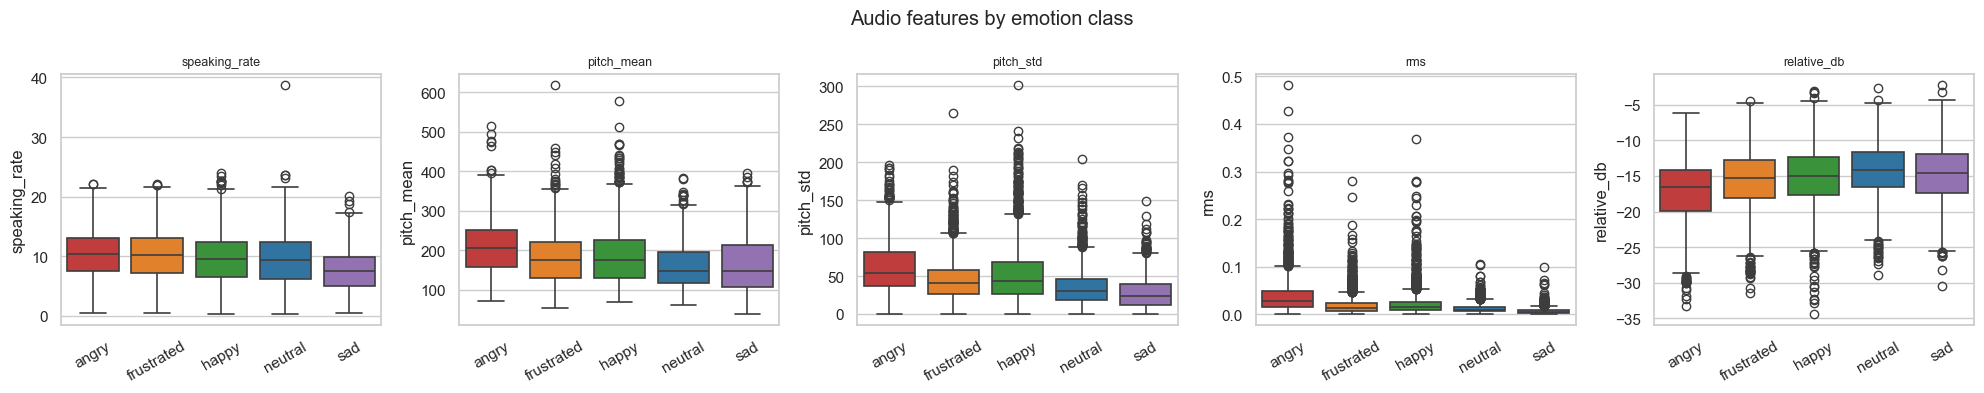

In [43]:
display(df.groupby('emotion')[audio_features].mean().round(3))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, audio_features):
    sns.boxplot(data=df, x='emotion', y=col, hue='emotion',
                palette=EMOTION_PALETTE, order=EMOTION_PALETTE.keys(),
                legend=False, linewidth=1.2, ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Audio features by emotion class')
plt.tight_layout()
plt.show()

**Key observations:**

- **`speaking_rate`** — angry utterances are slightly faster than sad; the difference is modest and distributions overlap heavily across all four classes.
- **`pitch_mean`** — angry and happy sit higher (median ~200 Hz) than neutral and sad (~150–170 Hz). The large spread and many high outliers reflect the mix of male (lower pitch) and female (higher pitch) speakers within each class.
- **`pitch_std`** — angry and happy show greater pitch variability (more expressive intonation); sad has the lowest variability, consistent with flat, monotone delivery.
- **`rms` / `relative_db`** — angry is the loudest class; sad is the quietest. Both features show the same pattern, confirming they measure the same underlying signal (energy).

Overall: `pitch_mean`, `rms`, and `relative_db` are the most emotion-discriminative features — they cleanly separate **high-arousal** (angry, happy) from **low-arousal** (neutral, sad) classes and are strong candidates for the Sprint 2 feature set.

### Class imbalance ratio (UAR context)

In [44]:
class_counts = df['emotion'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

print("Class counts:")
for cls, cnt in class_counts.items():
    bar = '█' * int(cnt / 50)
    print(f"  {cls:<12} {cnt:>5}  {bar}")

print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}x")
print("UAR (macro recall) is the right primary metric — weights all 5 classes equally.")

Class counts:
  frustrated    2917  ██████████████████████████████████████████████████████████
  happy         2632  ████████████████████████████████████████████████████
  neutral       1726  ██████████████████████████████████
  angry         1269  █████████████████████████
  sad           1250  █████████████████████████

Imbalance ratio (max/min): 2.33x
UAR (macro recall) is the right primary metric — weights all 5 classes equally.


---
## Findings Summary

1. **No missing values** — all columns are fully populated across 10,039 utterances.

2. **5-class label mapping** — only 245 rows (2.4%) dropped (minority labels only). `frustrated` is retained as the 5th class; `excited` is merged into `happy`. Final corpus: **9,794 utterances**.

3. **Audio analysis complete** — waveforms, FFT power spectra, mel-spectrograms, MFCCs (13 coefficients + deltas + delta-deltas), ZCR, spectral centroid/rolloff/bandwidth extracted for all 5 classes and saved in `df_audio_features`.

4. **Emotion signal in audio** — angry/frustrated show higher RMS energy and spectral centroid; sad shows lower pitch variability and higher MFCC-1 offset; neutral has the flattest spectral profile. Mel-spectrograms reveal clear visual differences between high- and low-arousal classes.

5. **Class imbalance is moderate** — UAR (macro recall) is the correct primary metric; it weights all 5 classes equally regardless of count.

6. **LOSO is valid** — all 5 emotion classes appear in every session. All 5 folds are structurally usable.

7. **VAD scores are discriminative** — `EmoAct` separates high-arousal (angry, frustrated, happy) from low-arousal (neutral, sad); `EmoVal` separates positive (happy) from negative (angry, frustrated, sad).

8. **Method is a confounder** — improvised dialogue yields more angry/frustrated/sad; scripted reading yields more neutral/happy. Include `method` as a covariate or run method-stratified evaluation.

**Next step:** Sprint 2 — Feature engineering: TF-IDF on `transcription` + MFCC/eGeMAPS from `df_audio_features` + early fusion baseline with LOSO cross-validation.